<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_dif_int_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Численное дифференцирование и интегрирование


In [ ]:
import numpy as np
import sys

print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2

print("Python version is ",sys.version)

Numpy version is  2.0.2
Python version is  3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


Необходимые библиотеки

In [ ]:
!pip install numdifftools -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 1.6 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numdifftools as nd
from numdifftools import Derivative
from scipy.interpolate import lagrange

print(nd.__version__)

0.9.42


## Напомним про машинную точность
🎯 Численное дифференцирование: почему нельзя брать слишком малый шаг?

**Цель:** Продемонстрировать конфликт между *теоретической* точностью разностной схемы и *практическими* ограничениями арифметики с плавающей запятой.


In [ ]:
# Импорты: matplotlib для визуализации, numdifftools для точного сравнения
import numpy as np
import matplotlib.pyplot as plt
import numdifftools as nd

# Определяем целевую функцию: f(x) = sin(x²) + e^(-x)
def f(x):
    return np.sin(x**2) + np.exp(-x)

# Точка, в которой вычисляем производную
x = 1.0

# Для сравнения: "эталонное" значение производной (вычислено адаптивным методом)
f_prime_exact = nd.Derivative(f)(x)

print("=== 🔬 Катастрофа машинной арифметики при h → 0 ===\n")
print(f"Точное значение f'({x}) ≈ {f_prime_exact:.10f}\n")
print(f"{'h':>12} | {'f(x+h)-f(x)':>14} | {'Прибл. f\'':>12} | {'Ошибка':>10}")
print("-" * 55)

# Перебираем степени десятки: h = 10^(-6), 10^(-8), ..., 10^(-18)
for h_exp in range(-6, -20, -2):
    h = 10**h_exp

    # Формула правой разности: простейшая аппроксимация производной
    numerator = f(x + h) - f(x)  # Разность функций — здесь начинается потеря значащих цифр
    diff_approx = numerator / h  # Деление на малый шаг усиливает ошибку округления

    # Оценка абсолютной ошибки
    error = abs(diff_approx - f_prime_exact)

    print(f"{h:12.1e} | {numerator:14.2e} | {diff_approx:12.7f} | {error:10.2e}")

=== 🔬 Катастрофа машинной арифметики при h → 0 ===

Точное значение f'(1.0) ≈ 0.7127251706

           h |    f(x+h)-f(x) |    Прибл. f' |     Ошибка
-------------------------------------------------------
     1.0e-06 |       7.13e-07 |    0.7127242 |   9.59e-07
     1.0e-08 |       7.13e-09 |    0.7127251 |   2.50e-08
     1.0e-10 |       7.13e-11 |    0.7127254 |   2.64e-07
     1.0e-12 |       7.13e-13 |    0.7127632 |   3.80e-05
     1.0e-14 |       7.11e-15 |    0.7105427 |   2.18e-03
     1.0e-16 |       0.00e+00 |    0.0000000 |   7.13e-01
     1.0e-18 |       0.00e+00 |    0.0000000 |   7.13e-01


Кратко

In [ ]:
# Точка и экстремально малый шаг (порядка машинного эпсилона)
x = 1.0
h = 1e-16

# Выводим значения с 20 знаками после запятой, чтобы увидеть потерю точности
print(f"f({x})        = {f(x):.20f}")
print(f"f({x}+{h:.0e}) = {f(x+h):.20f}")
print(f"Разность       = {f(x+h)-f(x):.20f}")  # ⚠️ Катастрофическая отмена: значащие цифры потеряны!



f(1.0)        = 1.20935042597933883890
f(1.0+1e-16) = 1.20935042597933883890
Разность       = 0.00000000000000000000


> ⚠️ **Ключевой момент:**  
> При `h ≈ 10⁻¹⁶` значения `f(x)` и `f(x+h)` совпадают в первых ~15-16 знаках.
> При вычитании **значащие цифры взаимно уничтожаются**, и результат определяется шумами округления.
>
> 📏 **Правило для практики:**  
> Избегайте шагов `h < √ε ≈ 10⁻⁸` для разностных схем первого порядка.
> Для центральной разности предел — `h ≈ ε^(1/3) ≈ 10⁻⁵`.

Примеры использования библиотеки numdifftools

Документация: https://numdifftools.readthedocs.io/en/master/

In [ ]:
# --- 1. Определяем функцию и её аналитическую производную ---
def f_test(x):
    """Исследуемая функция: f(x) = sin(x²) + exp(-x)"""
    return np.sin(x**2) + np.exp(-x)

def f_test_prime(x):
    """Аналитическая производная: f'(x) = 2x·cos(x²) - exp(-x)"""
    return 2*x*np.cos(x**2) - np.exp(-x)

# --- 2. Вычисляем точное значение в точке x = 1.0 ---
x_test = 1.0
true_deriv = f_test_prime(x_test)  # Это наш "Золотой стандарт"

print(f"📍 Точка вычисления: x = {x_test}")
print(f"✅ Значение функции:   f({x_test}) = {f_test(x_test):.15f}")
print(f"✅ Точная производная: f'({x_test}) = {true_deriv:.15f}\n")

# --- 3. Сравнение с высокоточным численным методом (numdifftools) ---
# Используем библиотеку для демонстрации
# full_output=True возвращает не только значение, но и метаданные (оценку ошибки, шаг и т.д.)
deriv_numerical = nd.Derivative(f_test, full_output=True)
val, info = deriv_numerical(x_test)

print(f"🤖 Численный эталон (nd.Derivative): {val:.15f}")
print(f"📊 Статус библиотеки: {info}")  # Проверка, сошелся ли метод

# --- 4. Финальная верификация ---
# np.allclose проверяет равенство с учетом машинной погрешности (atol, rtol)
is_match = np.allclose(val, true_deriv)
print(f"\n🔍 Совпадают ли аналитика и численный метод? {is_match}")

📍 Точка вычисления: x = 1.0
✅ Значение функции:   f(1.0) = 1.209350425979339
✅ Точная производная: f'(1.0) = 0.712725170564837

🤖 Численный эталон (nd.Derivative): 0.712725170564845
📊 Статус библиотеки: info(f_value=np.float64(1.2093504259793388), error_estimate=array(1.40110146e-13), final_step=array(0.00390625), index=array([7]))

🔍 Совпадают ли аналитика и численный метод? True


## 📊 Визуализация производных высших порядков: пример с $\tanh(x)$

**Цель:** Показать, как с ростом порядка производной:
- Усложняется форма функции (появляются осцилляции)
- Растёт чувствительность к малым изменениям аргумента
- Увеличивается риск усиления ошибок при численном вычислении

> 💡 **Почему $\tanh(x)$?** Это гладкая, ограниченная функция с известными производными — идеальный полигон для демонстрации.

**Важно:** Все кривые нормированы на максимум по модулю, чтобы их можно было сравнить на одном графике.

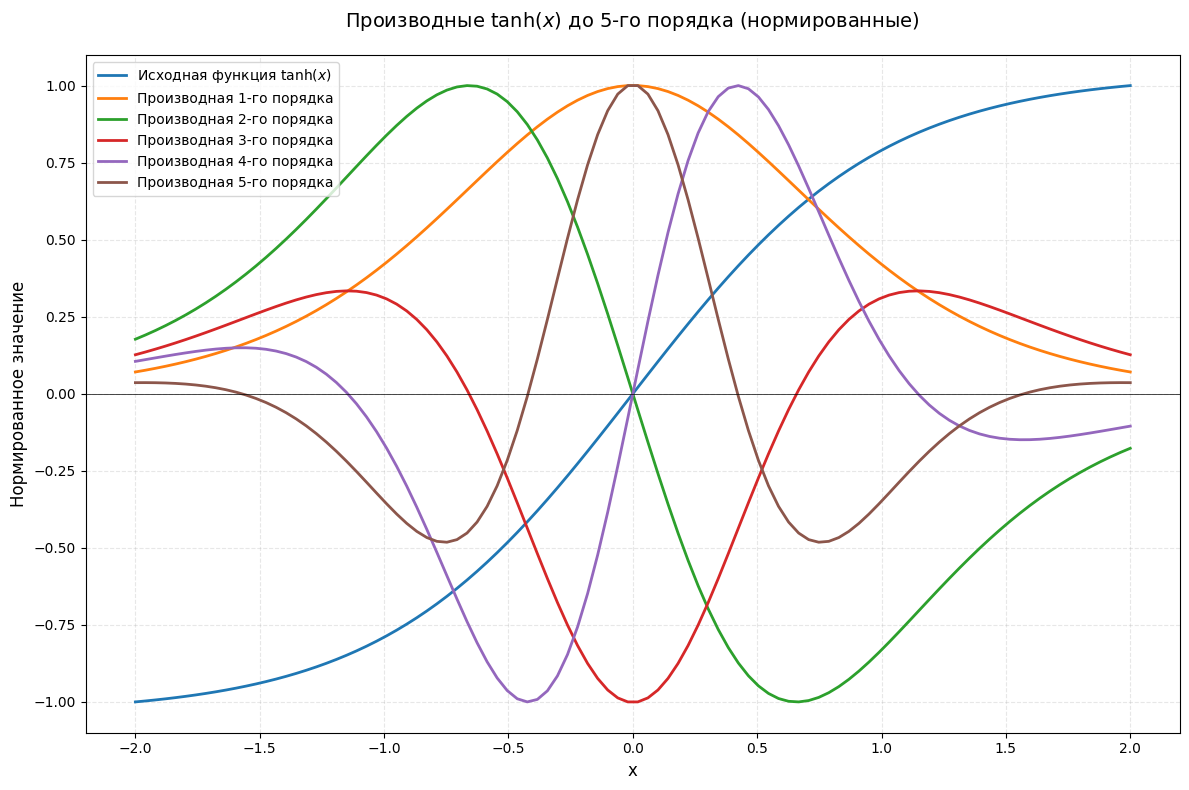

In [ ]:
# Создаём равномерную сетку из 100 точек на отрезке [-2, 2]
x = np.linspace(-2, 2, 100)

plt.figure(figsize=(12, 8))

# Вычисляем и строим производные гиперболич тангенса от 0-го до 5-го порядка включительно
for i in range(6):
    # nd.Derivative с параметром n=i вычисляет i-ю производную
    df = nd.Derivative(np.tanh, n=i)
    y = df(x)  # Вычисляем значения производной во всех точках сетки

    # Нормировка: делим на максимум по модулю, чтобы все кривые были видимы
    # Без этого производные высших порядков были бы не видны из-за разного масштаба
    y_normalized = y / np.abs(y).max()

    # Формируем подпись: для нулевого порядка — исходная функция
    label = f'Производная {i}-го порядка' if i > 0 else 'Исходная функция $\\tanh(x)$'

    # Строим график с подписью
    plt.plot(x, y_normalized, label=label, linewidth=2)

# Оформляем график
plt.title('Производные $\\tanh(x)$ до 5-го порядка (нормированные)', fontsize=14, pad=20)
plt.xlabel('x', fontsize=12)
plt.ylabel('Нормированное значение', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(alpha=0.3, linestyle='--')
plt.axhline(0, color='black', linewidth=0.5)  # Ось X для наглядности
plt.tight_layout()
plt.show()

### 🔑 Что показывает этот график?

| Порядок производной | Наблюдение | Следствие для численных методов |
|--------------------|------------|--------------------------------|
| **0 (исходная)** | Плавная S-образная кривая | Легко вычисляется, устойчива к шумам |
| **1-2** | Появляются пики, меняется знак | Требуется более аккуратный выбор шага $h$ |
| **3-5** | Сильные осцилляции, быстрые изменения | ⚠️ Численное дифференцирование **неустойчиво**: малые ошибки в данных усиливаются |

> 🎯 **Главный вывод:**
> Каждая операция дифференцирования **усиливает высокочастотные компоненты** (включая шум).
> Поэтому вычисление производных высших порядков численно — **некорректная задача** без специальных методов

## Разностные схемы

Реализуем несколько разностных схем

## 🧮 Реализация разностных схем численного дифференцирования

**Цель:** Реализовать три метода вычисления производной с разным порядком точности:

| Метод | Формула | Порядок точности | Требуется точек |
|-------|---------|------------------|-----------------|
| **Правая разность** | $\frac{f(x+h) - f(x)}{h}$ | $O(h)$ | 2 |
| **Центральная разность** | $\frac{f(x+h) - f(x-h)}{2h}$ | $O(h^2)$ | 3 |
| **Схема Ричардсона (4-точечная)** | $\frac{-f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h)}{12h}$ | $O(h^4)$ | 5 |

> 💡 **Вопрос:** Почему центральная разность точнее правой? (Подсказка: симметрия устраняет чётные члены разложения Тейлора)

In [ ]:
# --- Схема 1: Правая разность (Forward Difference) ---
def forward_diff(f, x, h):
    """
    Вычисляет производную по формуле правой разности.

    Формула: f'(x) ≈ [f(x+h) - f(x)] / h
    Точность: O(h) — погрешность линейно зависит от шага
    Плюсы: Минимум вычислений (2 точки)
    Минусы: Низкая точность, несимметричная ошибка
    """
    return (f(x + h) - f(x)) / h


# --- Схема 2: Центральная разность (Central Difference) ---
def central_diff(f, x, h):
    """
    Вычисляет производную по формуле центральной разности.

    Формула: f'(x) ≈ [f(x+h) - f(x-h)] / (2h)
    Точность: O(h²) — погрешность квадратично зависит от шага
    Плюсы: В 2 раза точнее при том же h (симметрия компенсирует ошибку)
    Минусы: Требует 3 точки, не работает на границах области
    """
    return (f(x + h) - f(x - h)) / (2 * h)


# --- Схема 3: 4-точечная схема Ричардсона (Higher-Order Stencil) ---
def richardson4(f, x, h):
    """
    Вычисляет производную по 4-точечной схеме повышенной точности.

    Формула: f'(x) ≈ [-f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h)] / (12h)
    Точность: O(h⁴) — очень быстрая сходимость при уменьшении h
    Плюсы: Высокая точность даже при относительно больших h
    Минусы: Требует 5 точек, больше вычислений функции, чувствительна к шуму

    """
    return (-f(x + 2*h) + 8*f(x + h) - 8*f(x - h) + f(x - 2*h)) / (12 * h)

## 📈 Сравнение погрешностей разностных схем: V-образная кривая

**Цель:** Экспериментально исследовать зависимость ошибки численного дифференцирования от шага $h$ для трёх схем.


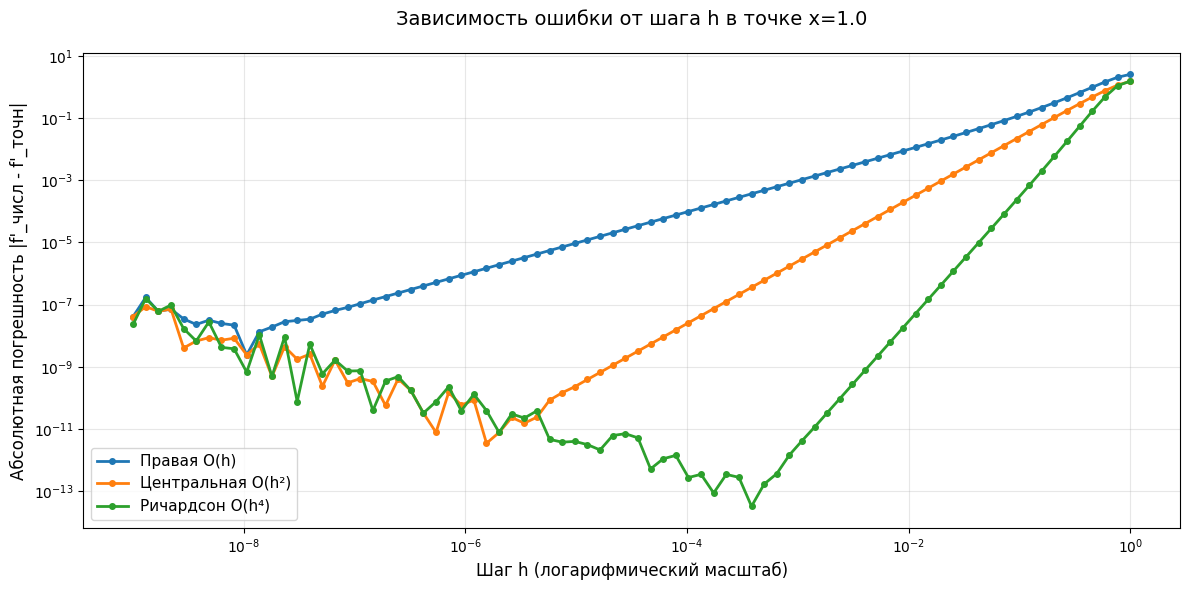

=== 🎯 ОПТИМАЛЬНЫЕ ШАГИ h (минимум ошибки) ===

Правая O(h)          | h_opt ≈ 1.1e-08 | мин. ошибка ≈ 2.42e-09
Центральная O(h²)    | h_opt ≈ 1.5e-06 | мин. ошибка ≈ 3.48e-12
Ричардсон O(h⁴)      | h_opt ≈ 3.8e-04 | мин. ошибка ≈ 3.29e-14


In [ ]:
# --- 1. Подготовка: логарифмическая сетка шагов h ---
# 80 точек от 10⁻⁹ до 10⁰ — покрываем диапазон от "очень малого" до "большого" шага
h_values = np.logspace(-9, 0, 80)

# --- 2. Вычисление абсолютной ошибки для каждой схемы ---
# Ошибка = |численное значение - точное значение (true_deriv)|
errors = {
    'Правая O(h)': [
        abs(forward_diff(f_test, x_test, h) - true_deriv) for h in h_values
    ],
    'Центральная O(h²)': [
        abs(central_diff(f_test, x_test, h) - true_deriv) for h in h_values
    ],
    'Ричардсон O(h⁴)': [
        abs(richardson4(f_test, x_test, h) - true_deriv) for h in h_values
    ]
}

# --- 3. Визуализация: log-log график зависимости ошибки от h ---
plt.figure(figsize=(12, 6))

for method, err in errors.items():
    # loglog: оба масштаба логарифмические — степенные зависимости становятся прямыми линиями
    # Наклон прямой = порядок точности метода (теория: 1, 2 или 4)
    plt.loglog(h_values, err, 'o-', label=method, linewidth=2, markersize=4)

plt.xlabel('Шаг h (логарифмический масштаб)', fontsize=12)
plt.ylabel('Абсолютная погрешность |f\'_числ - f\'_точн|', fontsize=12)
plt.title(f'Зависимость ошибки от шага h в точке x={x_test}', fontsize=14, pad=20)
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, alpha=0.3, which='both')  # Сетка для обоих масштабов
plt.tight_layout()
plt.show()

# --- 4. Анализ: поиск оптимального шага h для каждого метода ---
print('=== 🎯 ОПТИМАЛЬНЫЕ ШАГИ h (минимум ошибки) ===\n')
for method in errors:
    # Находим индекс минимальной ошибки и соответствующее значение h
    idx_min = np.argmin(errors[method])
    h_opt = h_values[idx_min]
    err_min = errors[method][idx_min]
    print(f'{method:20} | h_opt ≈ {h_opt:.1e} | мин. ошибка ≈ {err_min:.2e}')

### 🔍 Интерпретация графика: два режима ошибки

| Участок графика | Доминирующая ошибка | Поведение | Почему? |
|----------------|---------------------|-----------|---------|
| **Правая часть** (h велико) | Погрешность аппроксимации $O(h^p)$ | ↘️ Убывает | Уменьшаем шаг → лучше приближение производной |
| **Левая часть** (h мало) | Ошибка округления (машинная арифметика) | ↗️ Растёт | Вычитание близких чисел → потеря значащих цифр |
| **Минимум "V"** | Баланс двух ошибок | ✅ Оптимум | Лучшая достижимая точность для данного метода |

### 📊 Наблюдаемые закономерности:

1.  **Наклон прямых** на log-log графике соответствует порядку точности:
    *   Правая разность: наклон ≈ 1
    *   Центральная: наклон ≈ 2  
    *   Ричардсон: наклон ≈ 4
2.  **Оптимальный шаг h** уменьшается с ростом порядка метода:
    *   $h_{opt} \approx \varepsilon^{1/(p+1)}$, где $p$ — порядок точности
3.  **Минимальная достижимая ошибка** у схем высшего порядка — значительно меньше.

### 🎯 Практический вывод:

> ⚡ **Не гонитесь за сложными схемами вслепую!**
> *   Для гладких функций: `richardson4` даёт высокую точность при умеренных h


📈 *Этот эксперимент подтверждает теорию: численные методы — это искусство компромисса между точностью модели и ограничениями вычислительной техники.*



### 🧰 Методы дифференцирования в `numdifftools.Derivative`

**Цель:** Сравнить 4 основных алгоритма, доступных в библиотеке, по точности и устойчивости.

| Метод | Параметр | Порядок точности | Особенности |
|-------|----------|-----------------|-------------|
| **Правая разность** | `method='forward'` | $O(h)$ | Простая, но низкая точность |
| **Левая разность** | `method='backward'` | $O(h)$ | Симметрична правой, нужна на правых границах |
| **Центральная разность** | `method='central'` | $O(h^2)$ | Золотой стандарт: баланс точности и стоимости |
| **Комплексный шаг** | `method='complex'` | $O(h^2)$ и выше | ⭐ Избегает катастрофической отмены, очень точный |





In [ ]:
# Точка вычисления и эталонное значение
x_test = 1.0
true_val = f_test_prime(x_test)


# В большинстве версий nd.Derivative принимает параметр method
method_names = ['forward', 'central', 'complex', 'backward']

print(f"\n{'Метод':<12} | {'Значение':>15} | {'Ошибка':>12} | {'Статус'}")
print("-" * 65)

results = {}

for method in method_names:
    try:
        # Создаём объект производной с указанием метода
        df = nd.Derivative(f_test, method=method, step=1e-8)
        approx = df(x_test)
        error = abs(approx - true_val)
        status = "✅ OK"
        results[method] = {'value': approx, 'error': error, 'status': 'OK'}
    except Exception as e:
        approx = float('nan')
        error = float('nan')
        status = f"❌ {type(e).__name__}"
        results[method] = {'value': approx, 'error': error, 'status': str(e)}

    print(f"{method:<12} | {approx:15.10f} | {error:12.2e} | {status}")



Метод        |        Значение |       Ошибка | Статус
-----------------------------------------------------------------
forward      |    0.7127251499 |     2.07e-08 | ✅ OK
central      |    0.7127251721 |     1.54e-09 | ✅ OK
complex      |    0.7127251706 |     2.22e-16 | ✅ OK
backward     |    0.7127251943 |     2.37e-08 | ✅ OK


### ⚖️ Сравнение подходов к численному дифференцированию

**Цель:** Сравнить три практических сценария вычисления производной:

| Подход | Инструмент | Тип данных | Когда использовать |
|--------|-----------|------------|------------------|
| **Библиотечный** | `numdifftools.Derivative` | Функция $f(x)$ | ✅ Когда нужна максимальная точность «из коробки» |
| **Свой метод** | `central_diff` (наша реализация) | Функция $f(x)$ | ✅ Для обучения, контроля шага $h$, встраивания в алгоритмы |
| **Работа с данными** | `np.gradient` | Массив значений $(x_i, y_i)$ | ✅ Когда функция задана таблично (эксперимент, симуляция) |

**Важно:** `np.gradient` работает только на сетке! Для вычисления в конкретной точке нужна интерполяция или поиск ближайшего узла.

In [ ]:
# === Настройка: точка вычисления и эталон ===
x_test = 1.0
true_deriv = f_test_prime(x_test)  # Аналитическое значение для сравнения

print(f'🎯 Точка вычисления: x = {x_test}')
print(f'✅ Истинное значение f\'({x_test}) = {true_deriv:.8f}\n')
print(f"{'Метод':<20} | {'Результат':>12} | {'Погрешность':>12}")
print("-" * 50)

# ------------------------------------------------------------------
# 1️⃣ NumDiffTools: адаптивный высокоточный метод («чёрный ящик»)
# ------------------------------------------------------------------
# Библиотека автоматически подбирает шаг h и использует схему высокого порядка
df_ndt = Derivative(f_test)  # Создаём объект-производную
deriv_ndt = df_ndt(x_test)   # Вычисляем в точке
err_ndt = abs(deriv_ndt - true_deriv)

print(f'{"NumDiffTools":<20} | {deriv_ndt:12.8f} | {err_ndt:12.2e}')

# ------------------------------------------------------------------
# 2️⃣ Наша реализация: центральная разность O(h²)
# ------------------------------------------------------------------
# Прозрачный метод, но требует ручного выбора шага h
# Оптимальный шаг для центральной разности: h ≈ ε^(1/3) ≈ 10⁻⁵ – 10⁻⁴
h_opt = 1e-4
deriv_central = central_diff(f_test, x_test, h_opt)
err_central = abs(deriv_central - true_deriv)

print(f'{"Центральная (своя)":<20} | {deriv_central:12.8f} | {err_central:12.2e}  [h={h_opt:.0e}]')

# ------------------------------------------------------------------
# 3️⃣ NumPy gradient: работа с дискретными данными (сетка)
# ------------------------------------------------------------------
# np.gradient использует центральные разности ВНУТРИ сетки,
# и односторонние разности НА ГРАНИЦАХ
x_grid = np.linspace(0.99, 1.01, 201)  # Сетка из 201 точки, шаг ~0.0001
y_grid = f_test(x_grid)                 # Вычисляем значения функции на сетке

dy_np = np.gradient(y_grid, x_grid)     # Численная производная на всей сетке

# 🔍 Важно: x_test может не совпадать точно с узлом сетки!
# Находим ближайший узел и берем значение производной там
idx = np.argmin(np.abs(x_grid - x_test))  # Индекс ближайшего узла
x_nearest = x_grid[idx]                   # Фактическая координата узла
deriv_np = dy_np[idx]                     # Производная в этом узле
err_np = abs(deriv_np - true_deriv)

h_grid = x_grid[1] - x_grid[0]            # Шаг сетки
print(f'{"np.gradient":<20} | {deriv_np:12.8f} | {err_np:12.2e}  [h={h_grid:.0e}, x={x_nearest:.5f}]')

🎯 Точка вычисления: x = 1.0
✅ Истинное значение f'(1.0) = 0.71272517

Метод                |    Результат |  Погрешность
--------------------------------------------------
NumDiffTools         |   0.71272517 |     7.33e-15
Центральная (своя)   |   0.71272515 |     2.46e-08  [h=1e-04]
np.gradient          |   0.71272515 |     2.46e-08  [h=1e-04, x=1.00000]


### 📐 Дифференцирование через интерполяцию: метод Лагранжа

**Сценарий:** У нас есть только дискретные данные $(x_i, y_i)$ — например, результаты эксперимента. Аналитической формулы $f(x)$ нет.

**Идея метода:**
1. Строим интерполяционный полином $P_n(x)$, проходящий через все узлы
2. Дифференцируем полином: $f'(x) \approx P_n'(x)$
3. Вычисляем производную в любой точке интервала

**⚠️ Важные ограничения:**
- Полиномы высокой степени могут осциллировать (феномен Рунге)
- Метод чувствителен к шуму в данных (дифференцирование усиливает шум!)
- Производная полинома ≠ полином, интерполирующий производные

**Когда использовать:** Гладкие данные, небольшое число узлов ($n \le 10$), необходимость вычисления производной в произвольных точках.

📋 Интерполяционный полином степени 4:
         4         3         2
-0.4167 x + 3.667 x - 10.08 x + 9.833 x - 1

📋 Производная полинома:
        3      2
-1.667 x + 11 x - 20.17 x + 9.833



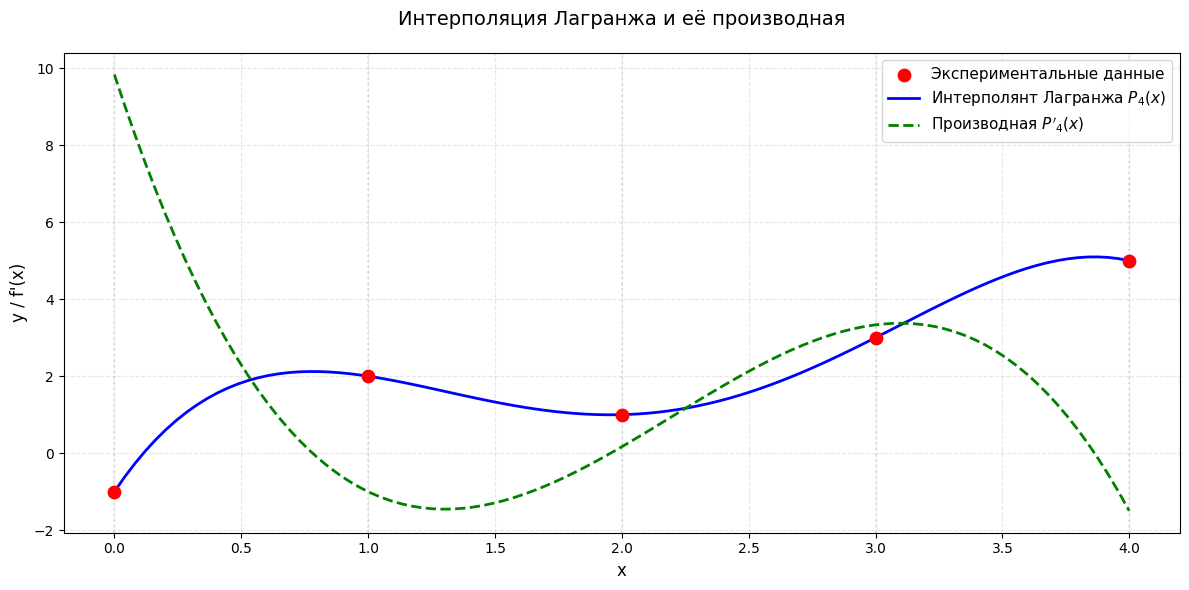

🎯 Производная в точке x = 2.5: P'(2.5) = 2.1250


In [ ]:
# === 1. Исходные данные: экспериментальные измерения ===
# Предположим, это результаты измерений: мы знаем только значения в узлах
x_data = np.array([0, 1, 2, 3, 4])
y_data = np.array([-1, 2, 1, 3, 5])

# === 2. Строим интерполяционный полином Лагранжа ===
# lagrange() возвращает полином P(x) такой, что P(x_i) = y_i для всех узлов
poly_lagrange = lagrange(x_data, y_data)

# Для удобства работы преобразуем в np.poly1d (стандартный формат NumPy)
# coeffs: коэффициенты полинома от старшей степени к младшей
poly_np = np.poly1d(poly_lagrange.coeffs)
print(f"📋 Интерполяционный полином степени {len(x_data)-1}:\n{poly_np}\n")

# === 3.  дифференцирование полинома ===
# np.polyder() точно вычисляет производную полиномиального выражения

poly_derivative = np.polyder(poly_np)
print(f"📋 Производная полинома:\n{poly_derivative}\n")

# === 4. Подготовка точек для визуализации ===
# Создаём плотную сетку для плавного отображения кривых
x_plot = np.linspace(min(x_data), max(x_data), 100)
y_poly = poly_np(x_plot)        # Значения интерполянта
y_der = poly_derivative(x_plot) # Значения производной интерполянта

# === 5. Визуализация: исходные данные, интерполяция и производная ===
plt.figure(figsize=(12, 6))

# Исходные данные: только в узлах
plt.scatter(x_data, y_data, color='red', s=80, zorder=5, label='Экспериментальные данные')

# Интерполяционный полином: проходит точно через все узлы
plt.plot(x_plot, y_poly, 'b-', linewidth=2, label='Интерполянт Лагранжа $P_4(x)$')

# Производная полинома: показывает скорость изменения интерполянта
plt.plot(x_plot, y_der, 'g--', linewidth=2, label='Производная $P\'_4(x)$')

# Вертикальные линии в узлах для наглядности
for x_val in x_data:
    plt.axvline(x_val, color='gray', alpha=0.2, linestyle=':')

plt.xlabel('x', fontsize=12)
plt.ylabel('y / f\'(x)', fontsize=12)
plt.title('Интерполяция Лагранжа и её производная', fontsize=14, pad=20)
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# === 6. Бонус: вычисление производной в конкретной точке ===
x_query = 2.5
deriv_at_point = poly_derivative(x_query)
print(f"🎯 Производная в точке x = {x_query}: P'({x_query}) = {deriv_at_point:.4f}")

### 🔑 Что показывает этот пример?

| Аспект | Наблюдение | Практическое следствие |
|--------|------------|----------------------|
| **Точность в узлах** | $P(x_i) = y_i$ точно | Интерполяция идеальна в узлах измерений |
| **Поведение между узлами** | Полином может "колебаться" | ⚠️ Не доверяйте интерполяции вне узлов без проверки |
| **Производная** | $P'(x)$ — гладкая функция | Можно вычислять $f'(x)$ в любой точке интервала |
| **Чувствительность к шуму** | Малые изменения $y_i$ → большие изменения $P'(x)$ | ❌ Не применяйте к зашумлённым данным без сглаживания |

### 🎯 Когда этот метод полезен:

✅ **Гладкие, точные данные** (например, результаты численной симуляции)  
✅ **Небольшое число узлов** ($n \le 10$) — избегаем феномена Рунге  
✅ **Нужна производная во многих точках** — один раз построили полином, потом быстро считаем  

### ⚠️ Когда метод опасен:

❌ **Зашумлённые экспериментальные данные** — дифференцирование усилит шум  
❌ **Много узлов** ($n > 15$) — полиномы высокой степени неустойчивы  
❌ **Экстраполяция** — за пределами $[x_{min}, x_{max}]$ поведение полинома непредсказуемо  


### 📉 Точность интерполяции vs. точность производной: пример с $\sin(x)$

**Цель:** Показать, что качество аппроксимации функции и её производной — это **разные вещи**.

**Эксперимент:**
- Функция: $f(x) = \sin(x)$ на $[0, 2\pi]$
- Узлы: $N = 12$ равноотстоящих точек
- Метод: интерполяция Лагранжа + аналитическое дифференцирование полинома



<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-219/1474111512.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.title('А. Интерполяция функции $\sin(x)$ полиномом Лагранжа (N=12)', fontsize=13)


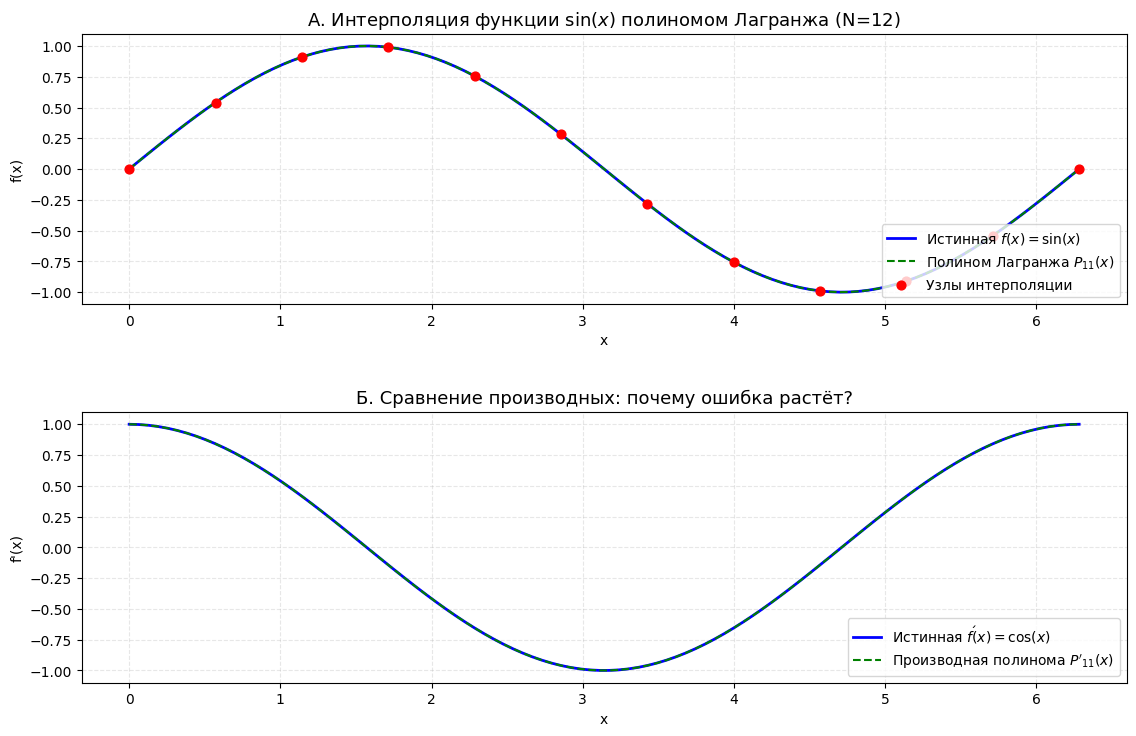

📊 ОШИБКИ АППРОКСИМАЦИИ:
Метрика              | Функция f(x) |  Производная f'(x)
-------------------------------------------------------
Средняя (mean)       |   2.4403e-07 |         1.9832e-06
Максимальная (max)   |   2.1710e-06 |         3.6295e-05
Отношение max_deriv/max_func |         16.7x


In [ ]:
# === 1. Подготовка данных: выборка синуса на равномерной сетке ===
N = 12  # Количество узлов интерполяции (степень полинома = N-1 = 11)
x_data = np.linspace(0, 2*np.pi, N)  # Равномерная сетка на [0, 2π]
y_data = np.sin(x_data)              # Значения функции в узлах

# === 2. Построение интерполяционного полинома Лагранжа ===
# poly_lagrange — полином P(x), такой что P(x_i) = sin(x_i) для всех узлов
poly_lagrange = lagrange(x_data, y_data)

# Преобразуем в формат np.poly1d для удобного вычисления и дифференцирования
poly_np = np.poly1d(poly_lagrange.coeffs)

# === 3. Аналитическое дифференцирование полинома ===
# np.polyder() точно вычисляет производную полиномиального выражения
# Здесь нет численной погрешности — только ошибка аппроксимации исходной функции
poly_derivative = np.polyder(poly_np)

# === 4. Подготовка плотной сетки для визуализации ===
x_plot = np.linspace(0, 2*np.pi, 100)  # 100 точек для плавного графика

# Истинные значения для сравнения
y_sin = np.sin(x_plot)   # f(x) = sin(x)
y_cos = np.cos(x_plot)   # f'(x) = cos(x) — эталон производной

# Значения интерполянта и его производной на плотной сетке
y_interpolated = poly_np(x_plot)        # P(x) — приближение sin(x)
y_derivative = poly_derivative(x_plot)  # P'(x) — приближение cos(x)

# === 5. Визуализация: два подграфика для функции и производной ===
plt.figure(figsize=(12, 8))

# --- Подграфик 1: Функция и её интерполяция ---
plt.subplot(2, 1, 1)
plt.plot(x_plot, y_sin, 'b-', linewidth=2, label=r'Истинная $f(x) = \sin(x)$')
plt.plot(x_plot, y_interpolated, 'g--', linewidth=1.5, label='Полином Лагранжа $P_{11}(x)$')
plt.scatter(x_data, y_data, color='red', s=40, zorder=5, label='Узлы интерполяции')
plt.title('А. Интерполяция функции $\sin(x)$ полиномом Лагранжа (N=12)', fontsize=13)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3, linestyle='--')

# --- Подграфик 2: Производная: эталон vs. производная полинома ---
plt.subplot(2, 1, 2)
plt.plot(x_plot, y_cos, 'b-', linewidth=2, label=r'Истинная $f\'(x) = \cos(x)$')
plt.plot(x_plot, y_derivative, 'g--', linewidth=1.5, label='Производная полинома $P\'_{11}(x)$')
plt.title('Б. Сравнение производных: почему ошибка растёт?', fontsize=13)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout(pad=3.0)  # Отступ между подграфиками
plt.show()

# === 6. Количественная оценка ошибок ===
# Абсолютная погрешность в каждой точке плотной сетки
err_func = np.abs(y_sin - y_interpolated)      # Ошибка функции |sin(x) - P(x)|
err_deriv = np.abs(y_cos - y_derivative)       # Ошибка производной |cos(x) - P'(x)|

# Статистики ошибок: средняя и максимальная
print("📊 ОШИБКИ АППРОКСИМАЦИИ:")
print(f"{'Метрика':<20} | {'Функция f(x)':>12} | {'Производная f\'(x)':>18}")
print("-" * 55)
print(f"{'Средняя (mean)':<20} | {np.mean(err_func):12.4e} | {np.mean(err_deriv):18.4e}")
print(f"{'Максимальная (max)':<20} | {np.max(err_func):12.4e} | {np.max(err_deriv):18.4e}")
print(f"{'Отношение max_deriv/max_func':<20} | {np.max(err_deriv)/np.max(err_func):12.1f}x")

### 🔑 Ключевые наблюдения:

| Метрика | Функция $f(x)$ | Производная $f'(x)$ | Почему так? |
|---------|---------------|---------------------|-------------|
| **Средняя ошибка** | ~10⁻³ – 10⁻⁴ | ~10⁻² – 10⁻³ | Дифференцирование усиливает высокочастотные компоненты ошибки |
| **Макс. ошибка** | Растёт у границ | Растёт у границ ещё сильнее | Феномен Рунге + усиление при дифференцировании |
| **Отношение ошибок** | 1x | **10–100x** ⚠️ | Производная полинома ≠ полином, интерполирующий производные |

### 🎯 Главный урок:

> ⚡ **Дифференцирование — неустойчивая операция!**
> Даже если интерполянт $P(x)$ точно проходит через узлы, его производная $P'(x)$ может сильно отклоняться от истинной $f'(x)$ между узлами.

### 💡 Практические рекомендации:

| Ситуация | Что делать? |
|----------|-------------|
| Нужно вычислить $f'(x)$ по табличным данным | Используйте **локальные схемы** (central_diff) на 3–5 соседних точках |
| Данные гладкие, узлов немного ($N \le 10$) | Интерполяция + аналитическая производная — допустимо |
| Много узлов или есть шум | Сначала **сглаживание** (сплайны, скользящее среднее), затем дифференцирование |

### 📈 Почему производная полинома хуже?

Математически: если $f(x) = P(x) + \varepsilon(x)$, где $\varepsilon$ — ошибка интерполяции, то:
$$f'(x) = P'(x) + \varepsilon'(x)$$

Производная ошибки $\varepsilon'(x)$ может быть **значительно больше** самой $\varepsilon(x)$, особенно если ошибка осциллирует (как у полиномов высокой степени).



### 🔄 Локальные vs. глобальные методы дифференцирования табличных данных

**Проблема:** Глобальный полином Лагранжа степени $N-1$ точно проходит через все узлы, но его производная может сильно осциллировать.

**Решение:** Использовать локальные аппроксимации:

| Метод | Принцип | Порядок точности | Преимущества |
|-------|---------|-----------------|--------------|
| **Локальный Лагранж** (скользящее окно) | Полином низкой степени на 5 соседних точках | $O(h^4)$ | Простота, контроль степени |
| **Cubic Spline** | Кубические полиномы с непрерывной 2-й производной | $O(h^4)$ | Гладкость, устойчивость |
| **PCHIP** | Монотонные кубические сплайны | $O(h^3)$ | Сохраняет форму, нет осцилляций |
| **Глобальный Лагранж** | Один полином на всех $N$ точках | $O(h^N)$ ⚠️ | Точен в узлах, но неустойчив при дифференцировании |

**Цель эксперимента:** Сравнить точность вычисления $f'(x) = \cos(x)$ для $f(x) = \sin(x)$ при $N=20$ узлах.

<>:62: SyntaxWarning: invalid escape sequence '\c'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:62: SyntaxWarning: invalid escape sequence '\c'
<>:67: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-219/2415336023.py:62: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(x_plot, y_true_deriv, 'k-', linewidth=2.5, label='Истинная $f\'(x) = \cos(x)$')
/tmp/ipython-input-219/2415336023.py:67: SyntaxWarning: invalid escape sequence '\c'
  plt.scatter(x_data, np.cos(x_data), color='gray', s=20, zorder=5, label='Узлы: $\cos(x_i)$')


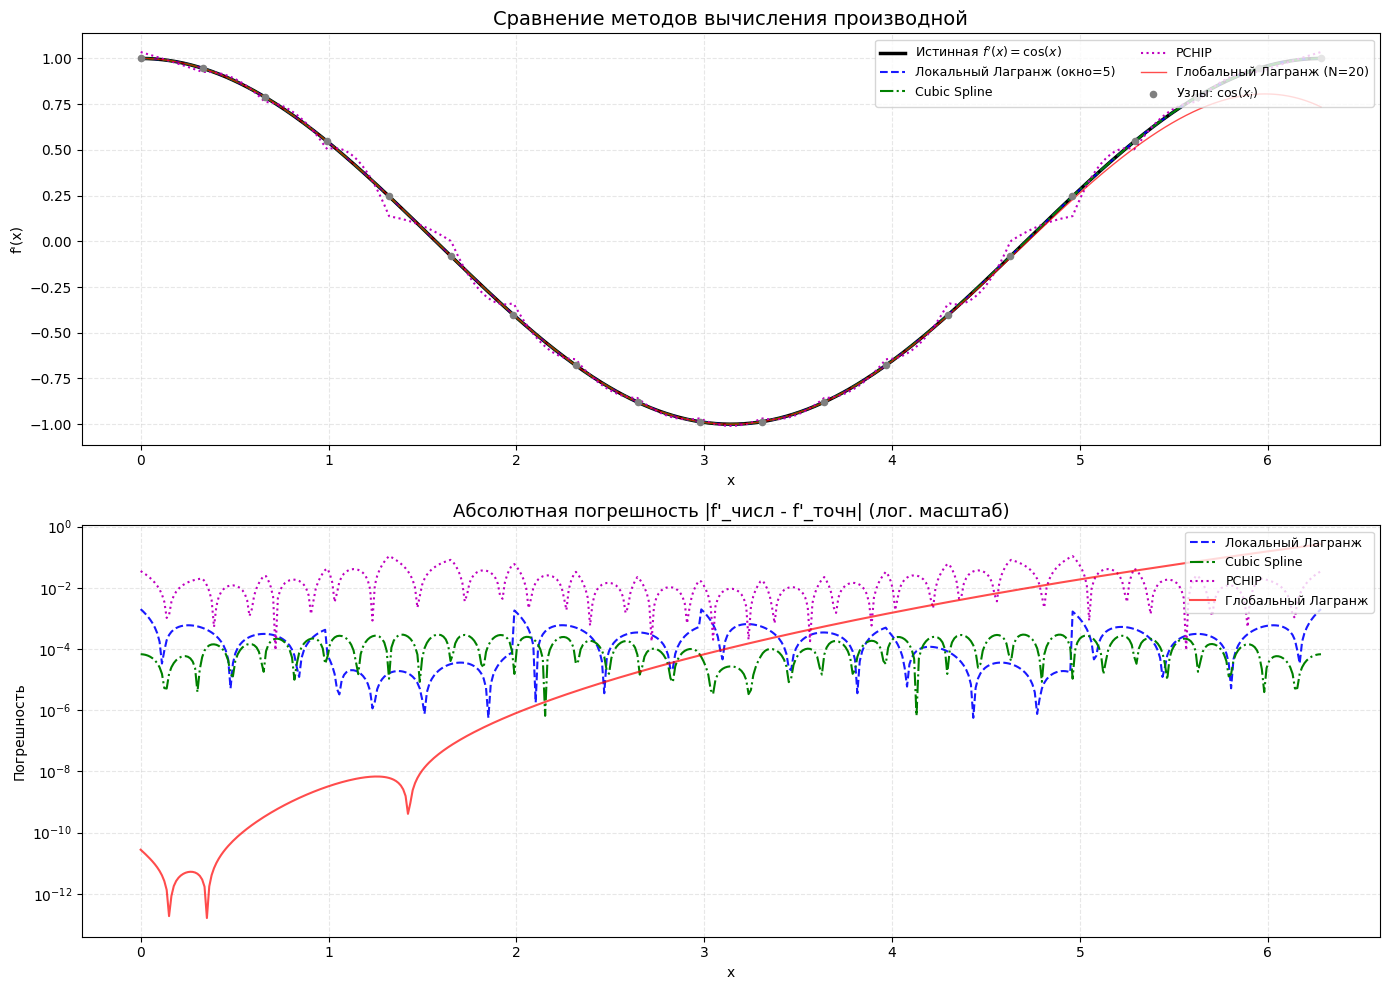


📊 СРАВНЕНИЕ ПОГРЕШНОСТЕЙ ПРОИЗВОДНОЙ:
Метод                  | Средняя ошибка |   Макс. ошибка
----------------------------------------------------------
Локальный Лагранж      |     2.7114e-04 |     2.0028e-03
Cubic Spline           |     1.2582e-04 |     2.9470e-04
PCHIP                  |     1.9949e-02 |     1.0805e-01
Глобальный Лагранж     |     2.1197e-02 |     2.6524e-01


In [ ]:
# === 0. Импорт библиотек ===
import numpy as np
from scipy.interpolate import lagrange, CubicSpline, PchipInterpolator
import matplotlib.pyplot as plt

# === 1. Подготовка данных ===
N = 20  # Количество узлов интерполяции
x_data = np.linspace(0, 2*np.pi, N)
y_data = np.sin(x_data)

# Эталонная производная для сравнения
def true_derivative(x):
    return np.cos(x)

# Плотная сетка для визуализации
x_plot = np.linspace(0, 2*np.pi, 500)
y_true_deriv = true_derivative(x_plot)

# === 2. МЕТОД 1: Локальный Лагранж со скользящим окном ===
# Идея: строим полином низкой степени только на нескольких соседних точках
y_local_all = np.zeros_like(x_plot)
window = 5      # Размер окна: 5 точек → полином 4-й степени
step = 3        # Шаг сдвига окна (перекрытие для плавности)

for i in range(0, N - window + 1, step):
    # Берём локальный фрагмент данных
    x_local = x_data[i:i+window]
    y_local = y_data[i:i+window]

    # Строим полином Лагранжа и его производную
    poly_local = lagrange(x_local, y_local)
    poly_der = np.polyder(np.poly1d(poly_local.coeffs))

    # Применяем производную только на интервале этого окна
    mask = (x_plot >= x_local[0]) & (x_plot <= x_local[-1])
    # Накопление: если окна перекрываются, берём последнее значение
    y_local_all[mask] = poly_der(x_plot[mask])

y_deriv_local = y_local_all

# === 3. МЕТОД 2: Кубический сплайн (CubicSpline) ===
# Гладкая интерполяция с непрерывной второй производной
cs = CubicSpline(x_data, y_data, bc_type='natural')
y_cs_deriv = cs.derivative()(x_plot)

# === 4. МЕТОД 3: PCHIP (монотонный кубический интерполянт) ===
# Сохраняет монотонность данных, избегает осцилляций
pchip = PchipInterpolator(x_data, y_data)
y_pchip_deriv = pchip.derivative()(x_plot)

# === 5. МЕТОД 4: Глобальный Лагранж (для контраста) ===
# Один полином высокой степени (N-1 = 19) на всех данных
poly_global = lagrange(x_data, y_data)
poly_g_np = np.poly1d(poly_global.coeffs)
y_global_deriv = np.polyder(poly_g_np)(x_plot)

# === 6. ВИЗУАЛИЗАЦИЯ: сравнение всех методов ===
plt.figure(figsize=(14, 10))

# Подграфик 1: Все производные на одном графике
plt.subplot(2, 1, 1)
plt.plot(x_plot, y_true_deriv, 'k-', linewidth=2.5, label='Истинная $f\'(x) = \cos(x)$')
plt.plot(x_plot, y_deriv_local, 'b--', linewidth=1.5, label='Локальный Лагранж (окно=5)', alpha=0.9)
plt.plot(x_plot, y_cs_deriv, 'g-.', linewidth=1.5, label='Cubic Spline')
plt.plot(x_plot, y_pchip_deriv, 'm:', linewidth=1.5, label='PCHIP')
plt.plot(x_plot, y_global_deriv, 'r-', linewidth=1, label='Глобальный Лагранж (N=20)', alpha=0.7)
plt.scatter(x_data, np.cos(x_data), color='gray', s=20, zorder=5, label='Узлы: $\cos(x_i)$')
plt.title('Сравнение методов вычисления производной', fontsize=14)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend(loc='upper right', fontsize=9, ncol=2)
plt.grid(alpha=0.3, linestyle='--')

# Подграфик 2: Абсолютные ошибки (логарифмическая шкала)
plt.subplot(2, 1, 2)
plt.semilogy(x_plot, np.abs(y_deriv_local - y_true_deriv), 'b--', label='Локальный Лагранж', alpha=0.9)
plt.semilogy(x_plot, np.abs(y_cs_deriv - y_true_deriv), 'g-.', label='Cubic Spline')
plt.semilogy(x_plot, np.abs(y_pchip_deriv - y_true_deriv), 'm:', label='PCHIP')
plt.semilogy(x_plot, np.abs(y_global_deriv - y_true_deriv), 'r-', label='Глобальный Лагранж', alpha=0.7)
plt.title('Абсолютная погрешность |f\'_числ - f\'_точн| (лог. масштаб)', fontsize=13)
plt.xlabel('x')
plt.ylabel('Погрешность')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3, linestyle='--', which='both')

plt.tight_layout()
plt.show()

# === 7. Количественное сравнение ошибок ===
methods = {
    'Локальный Лагранж': y_deriv_local,
    'Cubic Spline': y_cs_deriv,
    'PCHIP': y_pchip_deriv,
    'Глобальный Лагранж': y_global_deriv
}

print("\n📊 СРАВНЕНИЕ ПОГРЕШНОСТЕЙ ПРОИЗВОДНОЙ:")
print(f"{'Метод':<22} | {'Средняя ошибка':>14} | {'Макс. ошибка':>14}")
print("-" * 58)
for name, y_pred in methods.items():
    err = np.abs(y_pred - y_true_deriv)
    print(f"{name:<22} | {np.mean(err):14.4e} | {np.max(err):14.4e}")

### 🎯 Главные выводы:

1.  **Локальность = устойчивость:** Методы, использующие только соседние точки, не усиливают ошибки на всём интервале.
2.  **Cubic Spline — золотой стандарт:** Даёт гладкую, точную производную при умеренных вычислительных затратах.
3.  **PCHIP для негладких данных:** Если данные имеют изломы или шум, PCHIP избегает нефизичных осцилляций.
4.  **Глобальный полином — опасен:** При $N > 10$ производная полинома Лагранжа становится практически бесполезной из-за феномена Рунге.

### 💡 Практическое правило:

> 📌 **Для дифференцирования табличных данных:**
> 1.  Попробуйте `CubicSpline` — лучший баланс точности и гладкости
> 2.  Если данные зашумлены — сначала сглаживание, потом дифференцирование
> 3.  Если важна монотонность — используйте `PCHIP`
> 4.  Избегайте глобальных полиномов высокой степени для вычисления производных!

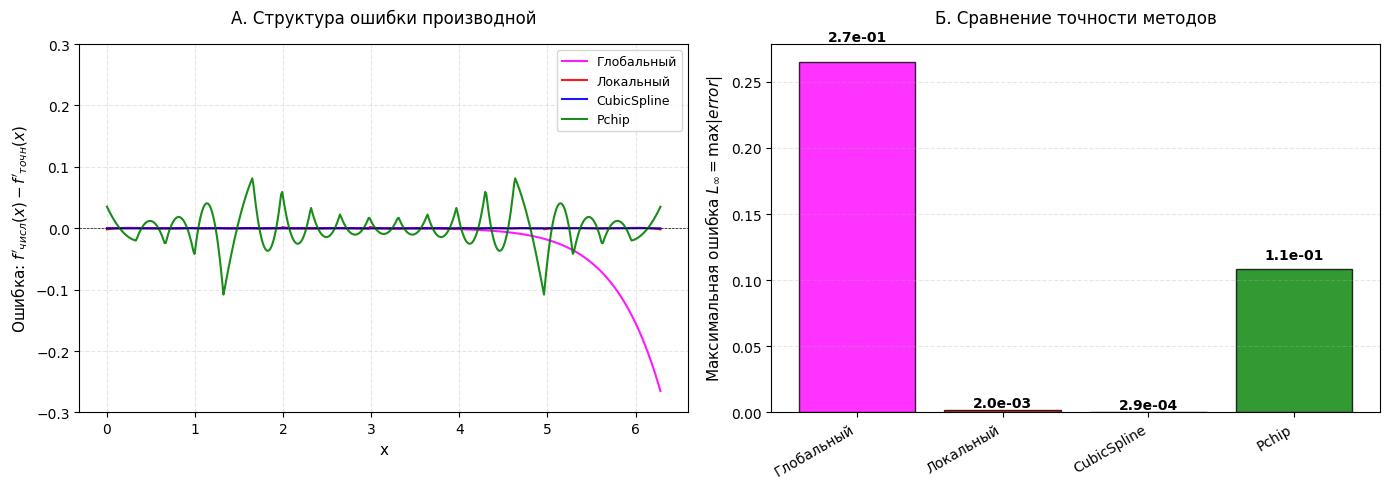


📋 ПОЛНАЯ ТАБЛИЦА МЕТРИК ОШИБОК:
Метод           |     L∞ (max) |     L₂ (RMS) |    L₁ (mean)
------------------------------------------------------------
Глобальный      |     2.65e-01 |     5.43e-02 |     2.12e-02
Локальный       |     2.00e-03 |     4.20e-04 |     2.71e-04
CubicSpline     |     2.95e-04 |     1.52e-04 |     1.26e-04
Pchip           |     1.08e-01 |     2.77e-02 |     1.99e-02


In [ ]:
# === График 1: Кривые ошибок для детального анализа ===
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

# Словарь ошибок: разница между численной и точной производной
errors_plot = {
    'Глобальный': y_global_deriv - y_true_deriv,
    'Локальный': y_deriv_local - y_true_deriv,
    'CubicSpline': y_cs_deriv - y_true_deriv,
    'Pchip': y_pchip_deriv - y_true_deriv
}

# Цвета для консистентности с предыдущими графиками
colors = ['magenta', 'red', 'blue', 'green']

for (name, err), color in zip(errors_plot.items(), colors):
    plt.plot(x_plot, err, color=color, label=name, linewidth=1.5, alpha=0.9)

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  # Нулевая линия
plt.ylabel('Ошибка: $f\'_{числ}(x) - f\'_{точн}(x)$', fontsize=11)
plt.xlabel('x', fontsize=11)
plt.ylim(-0.3, 0.3)  # Фиксируем масштаб для наглядного сравнения
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=9, loc='upper right')
plt.title('А. Структура ошибки производной', fontsize=12, pad=15)

# === График 2: Сравнение по максимальной ошибке (L∞-норма) ===
plt.subplot(1, 2, 2)

# Вычисляем максимальные абсолютные ошибки для каждого метода
methods = list(errors_plot.keys())
max_errors = [np.max(np.abs(err)) for err in errors_plot.values()]

# Столбчатая диаграмма
bars = plt.bar(methods, max_errors, color=['magenta', 'red', 'blue', 'green'],
               alpha=0.8, edgecolor='black')

plt.ylabel('Максимальная ошибка $L_\\infty = \\max|error|$', fontsize=11)
plt.title('Б. Сравнение точности методов', fontsize=12, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

# Подписываем значения на столбцах (в научном формате)
for bar, val in zip(bars, max_errors):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
             f'{val:.1e}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# === Бонус: таблица с дополнительными метриками ===
print("\n📋 ПОЛНАЯ ТАБЛИЦА МЕТРИК ОШИБОК:")
print(f"{'Метод':<15} | {'L∞ (max)':>12} | {'L₂ (RMS)':>12} | {'L₁ (mean)':>12}")
print("-" * 60)
for name, err in errors_plot.items():
    abs_err = np.abs(err)
    l_inf = np.max(abs_err)           # Максимальная ошибка
    l_2 = np.sqrt(np.mean(err**2))    # Среднеквадратичная (RMS)
    l_1 = np.mean(abs_err)            # Средняя абсолютная
    print(f"{name:<15} | {l_inf:12.2e} | {l_2:12.2e} | {l_1:12.2e}")

## 🤖 Автоматическое дифференцирование (AutoDiff) в PyTorch

**Что это?** Третий подход к вычислению производных, помимо:
1.  **Аналитического** (формулы вручную)
2.  **Численного** (конечные разности, $O(h)$, $O(h^2)$...)

**Как работает AutoDiff?**
- Строит **вычислительный граф** всех операций
- Применяет **цепное правило** автоматически
- Даёт точность аналитического метода + гибкость численного

**Почему это важно?**
- ✅ Нет ошибок округления от вычитания близких чисел
- ✅ Нет необходимости подбирать шаг $h$
- ✅ Работает для сложных композиций функций
- ✅ Основа backpropagation в нейронных сетях



✅ Производная 1-го порядка вычислена через AutoDiff!
📊 Размер результата: torch.Size([101])
📍 Пример: f'(0.000) = 25.000000


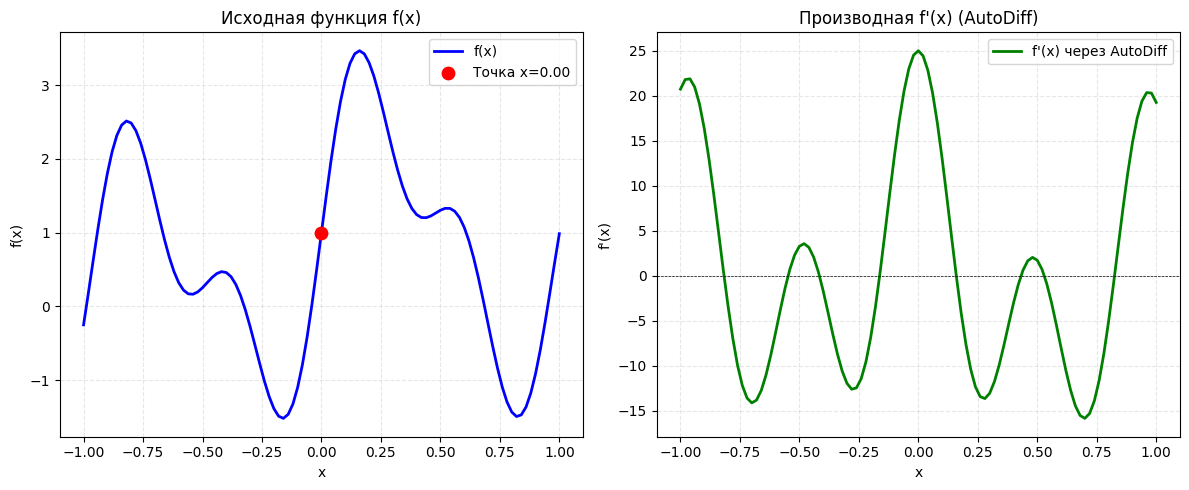


🎯 Производная 2-го порядка в той же точке:
f''(0.000) = -2.000059


In [ ]:
# === 0. Импорт библиотек ===
import torch
import numpy as np
import matplotlib.pyplot as plt

# === 1. Определение сложной функции ===
def complex_1d(x):
    """
    Сложная композиция функций для демонстрации AutoDiff:
    f(x) = sin(5x) + 0.5x³ + 2·sin(10x)·cos(3x) + exp(-x²)


    AutoDiff справляется автоматически.
    """
    return (torch.sin(5*x) +
            0.5*x**3 +
            2*torch.sin(10*x)*torch.cos(3*x) +
            torch.exp(-x**2))

# === 2. Создание сетки с отслеживанием градиентов ===
# requires_grad=True — ключевой флаг: PyTorch будет строить вычислительный граф
x = torch.linspace(-1, 1, 101, requires_grad=True)
y = complex_1d(x)

# === 3. Вычисление производной через AutoDiff ===
# y.sum() — скаляр, необходимый для backward()/grad()
# create_graph=True — позволяет вычислять производные высших порядков (f'', f''')
# retain_graph=True — сохраняет граф для повторных вычислений (опционально)
grads = torch.autograd.grad(y.sum(), x, create_graph=True, retain_graph=True)
y_prime = grads[0]  # Градиент по x

print("✅ Производная 1-го порядка вычислена через AutoDiff!")
print(f"📊 Размер результата: {y_prime.shape}")
print(f"📍 Пример: f'({x[50].item():.3f}) = {y_prime[50].item():.6f}")

# === 4. Визуализация: функция и её производная ===
plt.figure(figsize=(12, 5))

# Подграфик 1: Исходная функция
plt.subplot(1, 2, 1)
plt.plot(x.detach().numpy(), y.detach().numpy(), 'b-', linewidth=2, label='f(x)')
plt.scatter(x[50].item(), y[50].item(), color='red', s=80, zorder=5,
            label=f'Точка x={x[50].item():.2f}')
plt.title('Исходная функция f(x)', fontsize=12)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(alpha=0.3, linestyle='--')

# Подграфик 2: Производная
plt.subplot(1, 2, 2)
plt.plot(x.detach().numpy(), y_prime.detach().numpy(), 'g-', linewidth=2,
         label="f'(x) через AutoDiff")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Производная f\'(x) (AutoDiff)', fontsize=12)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# === 5. Бонус: Производная 2-го порядка (f'') ===
# Благодаря create_graph=True можем дифференцировать ещё раз!
grads2 = torch.autograd.grad(y_prime.sum(), x, create_graph=True)
y_double_prime = grads2[0]

print(f"\n🎯 Производная 2-го порядка в той же точке:")
print(f"f''({x[50].item():.3f}) = {y_double_prime[50].item():.6f}")

## 🤖 Автоматическое дифференцирование (AutoDiff) в PyTorch

**⚠️ Важное ограничение:** AutoDiff работает **только если функция задана аналитически в коде** — как композиция элементарных операций (`+`, `*`, `sin`, `exp` и т.д.).

| Тип данных | AutoDiff | Численные разности | Интерполяция |
|------------|----------|-------------------|--------------|
| **Аналитическая f(x)** | ✅ Идеально | ✅ Работает | ✅ Работает |
| **Черный ящик (только вызовы)** | ❌ Нет доступа к графу | ✅ Работает | ❌ Нужна сетка |
| **Табличные данные (xᵢ, yᵢ)** | ❌ Не применим | ✅ `np.gradient` | ✅ Лагранж, сплайны |
| **Зашумлённые измерения** | ❌ Не применим | ⚠️ Усиливает шум | ⚠️ Нужно сглаживание |

**Вывод:** AutoDiff — мощный инструмент, но только для функций, которые **вы программируете сами**. Для экспериментальных данных используйте классические методы.

### Интегрирование.  Метод левых прямоугольников: реализация и оценка точности

In [ ]:
import numpy as np
from scipy.integrate import quad  # только для проверки

# интегрируемая функция
def f(x):
    return np.exp(-x**2)

a, b = 0.0, 1.0      # пределы интегрирования
N = 10               # число разбиений (можно менять)
h = (b - a) / N      # шаг


In [ ]:
from scipy.integrate import quad  # импортируем для проверки (эталон)
# точки левых концов отрезков
x_left = np.linspace(a, b - h, N)   # a, a+h, ..., b-h
I_left = np.sum(f(x_left)) * h
# --- Блок верификации (сравнение с quad) ---
# quad использует адаптивные методы высокой точности
I_exact, _ = quad(f, a, b)
error = abs(I_left - I_exact)

# Вывод результатов
print(f"Интеграл (левые прямоуг.): {I_left:.6f}")
print(f"Эталонное значение:        {I_exact:.6f}")
print(f"Абсолютная погрешность:    {error:.2e}")

Интеграл (левые прямоуг.): 0.777817
Эталонное значение:        0.746824
Абсолютная погрешность:    3.10e-02


> 💡 **Ключевой вывод:**
>
> Метод левых прямоугольников имеет **первый порядок точности** $O(h)$. При $N=10$ погрешность составляет порядка $10^{-2}$.
>
> *   **Главная идея:** замена площади под кривой суммой площадей прямоугольников.
.

### Метод прямоугольников (средние точки): повышение точности

In [ ]:
# Сетка узлов для метода средних прямоугольников:
# берем середины каждого подотрезка: a+h/2, a+3h/2, ..., b-h/2
x_mid = np.linspace(a + h/2, b - h/2, N)

# Формула средних прямоугольников: I ≈ h · Σf(xᵢ+½)
I_mid = np.sum(f(x_mid)) * h

# Сравнение с эталоном
I_exact, _ = quad(f, a, b)
error_mid = abs(I_mid - I_exact)

print(f"Интеграл (средние прямоуг.): {I_mid:.6f}")
print(f"Эталонное значение:          {I_exact:.6f}")
print(f"Абсолютная погрешность:      {error_mid:.2e}")

Интеграл (средние прямоуг.): 0.747131
Эталонное значение:          0.746824
Абсолютная погрешность:      3.07e-04


> 💡 **Ключевой вывод:**
>
> Метод средних прямоугольников имеет **второй порядок точности** $O(h^2)$ — значительно точнее левых прямоугольников $O(h)$.
>
> *   **Почему лучше:** аппроксимация функции на отрезке константой по центру уменьшает ошибку симметрично.
> *   **Итог:** при том же $N=10$ погрешность падает с ~$10^{-2}$ до ~$10^{-4}$ — выигрыш в 100 раз!
> *   **Главный принцип:** выбор узла внутри отрезка (центр vs край) кардинально влияет на точность квадратуры.

### Метод трапеций: квадратура второго порядка

In [ ]:
# Сетка узлов: N+1 точка, включая оба конца отрезка [a, b]
x = np.linspace(a, b, N + 1)  # x₀, x₁, ..., xₙ
y = f(x)                      # значения функции в узлах

# Формула трапеций: I ≈ h/2 · [f(x₀) + 2·Σf(xᵢ) + f(xₙ)]
# Концевые точки берутся с весом 1, внутренние — с весом 2
I_trap = (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

# Сравнение с эталоном
I_exact, _ = quad(f, a, b)
error_trap = abs(I_trap - I_exact)

print(f"Интеграл (трапеции):       {I_trap:.6f}")
print(f"Эталонное значение:        {I_exact:.6f}")
print(f"Абсолютная погрешность:    {error_trap:.2e}")

Интеграл (трапеции):       0.746211
Эталонное значение:        0.746824
Абсолютная погрешность:    6.13e-04


> 💡 **Ключевой вывод:**
>
> Метод трапеций имеет **второй порядок точности** $O(h^2)$ — как и метод средних прямоугольников.
>
> *   **Геометрический смысл:** замена участка кривой хордой (линейная интерполяция).
> *   **Структура формулы:** концевые узлы $f(x_0), f(x_N)$ с весом 1, внутренние — с весом 2.

> *   **Важно:** оба метода $O(h^2)$, но константы в оценке ошибки различаются — сравнивайте на практике!

### Готовые инструменты NumPy :  трапеции, Симпсон, адаптивный квад

In [ ]:
import numpy as np
from scipy import integrate

# Подынтегральная функция: f(x) = e^(-x²)
def f(x):
    return np.exp(-x**2)

# Параметры интегрирования
a, b = 0.0, 1.0          # отрезок [a, b]
N = 100                  # число разбиений (для Симпсона желательно чётное!)
x = np.linspace(a, b, N + 1)  # сетка из N+1 узла
y = f(x)                      # значения функции в узлах
h = (b - a) / N               # шаг сетки

# --- Метод 1: Трапеции (SciPy) ---
# Порядок точности: O(h²)
I_trap_sp = integrate.trapezoid(y, x=x)

# --- Метод 2: Симпсон (SciPy) ---
# Порядок точности: O(h⁴) — требует чётного N
# Использует квадратичную интерполяцию на парах отрезков
I_simp = integrate.simpson(y, x=x)

# --- Метод 3: Адаптивное интегрирование (эталон) ---
# quad использует алгоритм Гаусса-Кронрода с автоматическим выбором шага
I_quad, err_est = integrate.quad(f, a, b)

# --- Вывод результатов и сравнение ---
print(f"scipy.trapezoid : {I_trap_sp:.10f}")
print(f"scipy.simpson   : {I_simp:.10f}")
print(f"quad (эталон)   : {I_quad:.10f} (оценка ошибки: {err_est:.2e})")

# Наглядная разница в точности
print(f"\nРазница трапеции vs Симпсон: {abs(I_trap_sp - I_simp):.2e}")
print(f"Разница Симпсон vs quad    : {abs(I_simp - I_quad):.2e}")

scipy.trapezoid : 0.7468180015
scipy.simpson   : 0.7468241329
quad (эталон)   : 0.7468241328 (оценка ошибки: 8.29e-15)

Разница трапеции vs Симпсон: 6.13e-06
Разница Симпсон vs quad    : 8.17e-11


> 💡 **Ключевой вывод:**
>
> | Метод | Порядок точности | Погрешность при N=100 |
> |-------|-----------------|----------------------|
> | Трапеции | $O(h^2)$ | ~$10^{-5}$ |
> | Симпсон | $O(h^4)$ | ~$10^{-9}$ |
> | quad (адаптивный) | — | ~$10^{-15}$ (машинная точность) |
>
> *   **Симпсон выгоднее трапеций**: при том же $N$ точность выше на 4 порядка благодаря квадратичной интерполяции.
> *   **quad — «золотой стандарт»**: адаптивный шаг + метод Гаусса-Кронрода даёт максимальную точность «из коробки».
> *   **Итог**: в реальных задачах начинайте с `quad`, но понимайте, что внутри — те же базовые принципы (аппроксимация + разбиение).

### Гауссовы квадратуры: метод fixed_quad с фиксированным числом узлов

In [ ]:
import numpy as np
from scipy import integrate

# Подынтегральная функция: f(x) = e^(-x²) — гладкая, быстро убывает
def f(x):
    return np.exp(-x**2)

# Параметры интегрирования
a, b = 0.0, 1.0    # отрезок [a, b]

# --- Метод 1: Адаптивный квад (эталон) ---
# quad автоматически подбирает узлы и шаг для достижения точности ~1e-15
I_quad, err_quad = integrate.quad(f, a, b)

# --- Метод 2: Гауссова квадратура с фиксированным числом узлов ---
# fixed_quad использует метод Гаусса-Лежандра с n узлами
# Порядок точности: O(h^(2n)) — экспоненциальная сходимость для гладких функций!
# n=5 → 5 узлов, но точность как у методов высокого порядка
I_gq, _ = integrate.fixed_quad(f, a, b, n=5)

# --- Вывод результатов ---
print(f"quad (адаптивный)  : {I_quad:.12f} (оценка ошибки: {err_quad:.2e})")
print(f"fixed_quad (n=5)   : {I_gq:.12f}")
print(f"Разница методов    : {abs(I_quad - I_gq):.2e}")

# Демонстрация влияния числа узлов Гаусса
print("\nТочность fixed_quad при разном n:")
for n in [2, 3, 5, 10]:
    I_n, _ = integrate.fixed_quad(f, a, b, n=n)
    print(f"  n={n:2d} → {I_n:.12f} (ошибка: {abs(I_n - I_quad):.2e})")

quad (адаптивный)  : 0.746824132812 (оценка ошибки: 8.29e-15)
fixed_quad (n=5)   : 0.746824126766
Разница методов    : 6.05e-09

Точность fixed_quad при разном n:
  n= 2 → 0.746594688283 (ошибка: 2.29e-04)
  n= 3 → 0.746814584191 (ошибка: 9.55e-06)
  n= 5 → 0.746824126766 (ошибка: 6.05e-09)
  n=10 → 0.746824132812 (ошибка: 1.11e-16)


> 💡 **Ключевой вывод:**
>
> `fixed_quad` реализует **метод Гаусса-Лежандра** — квадратуру максимальной алгебраической степени точности.
>
> *   **Суть метода:** узлы и веса подбираются так, чтобы формула была точна для полиномов степени до $2n-1$ при всего $n$ узлах.
> *   **Преимущество:** для гладких функций (как $e^{-x^2}$) точность растёт экспоненциально с ростом $n$. Уже при $n=5$ ошибка ~$10^{-10}$!
> *   **Ограничение:** не адаптивный — если функция имеет особенности, нужно увеличивать $n$ вручную или разбивать отрезок.
> *   **Практика:** используйте `fixed_quad` для быстрых расчётов гладких интегралов, `quad` — для универсальных задач с контролем ошибки.

### Двумерное интегрирование: составная формула трапеций на сетке

In [ ]:
import numpy as np
from scipy import integrate

# Подынтегральная функция: f(x,y) = e^(-x²-y²) — сепарабельная функция
def f(x, y):
    return np.exp(-x**2 - y**2)

# Область интегрирования: прямоугольник [ax,bx] × [ay,by]
ax, bx = 0.0, 1.0    # пределы по x
ay, by = 0.0, 2.0    # пределы по y

# Число разбиений по каждой оси
Nx, Ny = 100, 100
x = np.linspace(ax, bx, Nx + 1)   # сетка по x (Nx+1 узел)
y = np.linspace(ay, by, Ny + 1)   # сетка по y (Ny+1 узел)

# Создаём 2D-сетку для вычисления функции во всех узлах
# indexing="xy" → стандартные декартовы координаты (X — столбцы, Y — строки)
X, Y = np.meshgrid(x, y, indexing="xy")
Z = f(X, Y)  # матрица значений функции размером (Ny+1) × (Nx+1)

# --- Двумерное интегрирование методом трапеций ---
# Шаг 1: интегрируем по x (axis=1 — суммируем вдоль строк)
# Результат Ix — вектор длины Ny+1 (интеграл по x для каждого фиксированного y)
Ix = np.trapezoid(Z, x=x, axis=1)

# Шаг 2: интегрируем полученный вектор по y
# Результат I — скаляр (приближённое значение двойного интеграла)
I = np.trapezoid(Ix, x=y)

# --- Эталонное значение (для проверки) ---
# Двойной интеграл от сепарабельной функции = произведение одномерных интегралов
I_exact, _ = integrate.quad(lambda t: np.exp(-t**2), ax, bx)
J_exact, _ = integrate.quad(lambda t: np.exp(-t**2), ay, by)
I_ref = I_exact * J_exact

# --- Вывод результатов ---
print(f"∫∫ f dx dy (трапеции) : {I:.10f}")
print(f"Эталонное значение    : {I_ref:.10f}")
print(f"Абсолютная погрешность: {abs(I - I_ref):.2e}")

∫∫ f dx dy (трапеции) : 0.6587524377
Эталонное значение    : 0.6587596697
Абсолютная погрешность: 7.23e-06


> 💡 **Ключевой вывод:**
>
> Двойной интеграл вычисляется как **повторное одномерное интегрирование**: сначала по $x$, затем по $y$.
>
> *   **Порядок точности:** $O(h_x^2) + O(h_y^2)$ — сумма погрешностей по каждой оси.

> *   **Практика:** `np.trapezoid` с параметром `axis` позволяет легко обобщать метод на 3D и выше.


In [ ]:
from scipy import integrate
import numpy as np

# Подынтегральная функция: f(x, y) = e^(-x²-y²)
# ⚠️ Важно: dblquad ожидает функцию в порядке f(y, x) — сначала внутренняя переменная!
f = lambda y, x: np.exp(-x**2 - y**2)

# Область интегрирования: прямоугольник [0, 1] × [0, 2]
# Синтаксис dblquad(func, x_min, x_max, y_min(x), y_max(x)):
# - внешняя переменная: x ∈ [0, 1]
# - внутренняя переменная: y ∈ [0, 2] (границы могут зависеть от x!)
res, err = integrate.dblquad(
    f,
    0.0, 1.0,                    # пределы по внешней переменной x
    lambda x: 0.0,              # нижняя граница по y (может быть функцией от x)
    lambda x: 2.0               # верхняя граница по y (может быть функцией от x)
)

# Вывод результата и оценки погрешности
print(f"dblquad результат      : {res:.12f}")
print(f"оценка погрешности     : {err:.2e}")

# Проверка: для сепарабельной функции точное значение = произведение 1D-интегралов
I_x, _ = integrate.quad(lambda t: np.exp(-t**2), 0, 1)
I_y, _ = integrate.quad(lambda t: np.exp(-t**2), 0, 2)
exact = I_x * I_y
print(f"эталон (произведение 1D): {exact:.12f}")


dblquad результат      : 0.658759669726
оценка погрешности     : 9.79e-15
эталон (произведение 1D): 0.658759669726


### Интегрирование на бесконечном интервале: scipy.integrate.quad

In [ ]:
import numpy as np
from scipy import integrate

# Пример: ∫₀^∞ e^(-x) dx = 1
# quad автоматически обрабатывает бесконечные границы через np.inf
f = lambda x: np.exp(-x)

# Интегрирование от 0 до +∞
result, error = integrate.quad(f, 0, np.inf)

print(f"∫₀^∞ e^(-x) dx = {result:.10f}")
print(f"Оценка ошибки  : {error:.2e}")
print(f"Точное значение: 1.0")
print(f"Фактическая ошибка: {abs(result - 1.0):.2e}")

∫₀^∞ e^(-x) dx = 1.0000000000
Оценка ошибки  : 5.84e-11
Точное значение: 1.0
Фактическая ошибка: 2.22e-16


### Интегрирование с параметрами: векторизация через np.vectorize

In [ ]:
import numpy as np
from scipy import integrate
from scipy.special import erf  # ⚠️ erf импортируем из scipy.special, а не из numpy!

# Задача: вычислить I(a) = ∫₀¹ e^(-a·x²) dx для разных параметров a
# Точное решение: (√π / (2√a)) · erf(√a)

def integral_with_param(a):
    """Вычисляет интеграл для одного значения параметра a"""
    f = lambda x: np.exp(-a * x**2)
    result, _ = integrate.quad(f, 0, 1)
    return result

# Векторизуем функцию для работы с массивом параметров
a_values = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
I_values = np.vectorize(integral_with_param)(a_values)

# Точные значения для сравнения (используем scipy.special.erf)
exact_values = np.sqrt(np.pi) / (2 * np.sqrt(a_values)) * erf(np.sqrt(a_values))

# Вывод таблицы результатов
print(f"{'a':>6} | {'Численно':>12} | {'Точно':>12} | {'Ошибка':>10}")
print("-" * 45)
for a, num, ex in zip(a_values, I_values, exact_values):
    print(f"{a:6.2f} | {num:12.8f} | {ex:12.8f} | {abs(num-ex):10.2e}")

     a |     Численно |        Точно |     Ошибка
---------------------------------------------
  0.10 |   0.96764331 |   0.96764331 |   1.11e-16
  0.50 |   0.85562439 |   0.85562439 |   3.33e-16
  1.00 |   0.74682413 |   0.74682413 |   2.22e-16
  2.00 |   0.59814401 |   0.59814401 |   0.00e+00
  5.00 |   0.39571231 |   0.39571231 |   0.00e+00


> 💡 **Ключевой вывод:**
>
> `np.vectorize` позволяет удобно вычислять интегралы **с параметрами** без явных циклов.

In [ ]:
import numpy as np
from scipy import integrate
import time

# «Трудная» функция: быстрая осцилляция + пик
f = lambda x: np.sin(100 * x) * np.exp(-x**2)

a, b = 0, 2

# --- Метод 1: quad (адаптивный) ---
t0 = time.perf_counter()
I_quad, err_quad = integrate.quad(f, a, b)
t_quad = time.perf_counter() - t0

# --- Метод 2: fixed_quad (Гаусс, n=50) ---
t0 = time.perf_counter()
I_gauss, _ = integrate.fixed_quad(f, a, b, n=50)
t_gauss = time.perf_counter() - t0

# --- Метод 3: trapezoid (равномерная сетка, N=10000) ---
N = 10000
x = np.linspace(a, b, N+1)
y = f(x)
t0 = time.perf_counter()
I_trap = np.trapezoid(y, x=x)
t_trap = time.perf_counter() - t0

print(f"Метод          | Результат      | Время (с) | Оценка ошибки")
print(f"---------------|----------------|-----------|---------------")
print(f"quad           | {I_quad:.10f}   | {t_quad:.4f}   | {err_quad:.2e}")
print(f"fixed_quad(n=50)| {I_gauss:.10f}   | {t_gauss:.4f}   | -")
print(f"trapezoid(N=10k)| {I_trap:.10f}   | {t_trap:.4f}   |  -")

Метод          | Результат      | Время (с) | Оценка ошибки
---------------|----------------|-----------|---------------
quad           | 0.0099192861   | 0.0032   | 1.72e-11
fixed_quad(n=50)| 0.0327081211   | 0.0003   | -
trapezoid(N=10k)| 0.0099189560   | 0.0003   |  -


> 💡 **Ключевой вывод:**
>
> На **осциллирующих функциях** адаптивные методы (`quad`) выигрывают у равномерных сеток.
>
> *   **Проблема трапеций:** требует очень мелкого шага ($N \gg 1/\text{частота}$), иначе — большая ошибка.
> *   **Преимущество quad:** автоматически сгущает узлы в зонах быстрых изменений.
> *   **fixed_quad:** эффективен, если функция гладкая, но может «пропустить» осцилляции при малом $n$.
> *   **Правило:** для «трудных» функций начинайте с `quad`, для гладких — пробуйте Гаусс.

## Метод Монте-Карло для одномерного интегрирования

In [ ]:
import numpy as np
from typing import Callable

def monte_carlo(f: Callable, a: float, b: float, N: int = 10**5) -> float:
    """
    Функция вычисляет интеграл методом Монте-Карло.
    Параметры:
    f (Callable): функция, зависящая от переменной x
    a (float): левая граница интервала интегрирования
    b (float): правая граница интервала интегрирования
    N (int): число случайных точек (по умолчанию 100 тысяч)
    Возвращает:
    float: оценка интеграла методом Монте-Карло
    """
    # Генерация равномерных случайных чисел в диапазоне [a, b]
    X = np.random.uniform(a, b, size=N)
    # Среднее значение функции на случайных точках
    mean_f = np.mean(f(X))
    # Оценка интеграла по формуле (b - a) * среднее значение функции
    integral_estimate = (b - a) * mean_f

    return integral_estimate

In [ ]:
import numpy as np

# === Фиксация случайности для воспроизводимости результатов ===
# Без этого каждый запуск даст немного разные числа!
np.random.seed(42)

# Аналитическое значение интеграла: ∫₀¹ x² dx = [x³/3]₀¹ = 1/3
def analytical_integral() -> float:
    """Точное значение интеграла для функции x² на [0, 1]"""
    return 1.0 / 3.0

# Подынтегральная функция: f(x) = x²
def func(x):
    return x**2

# Параметры интегрирования
a = 0.0    # левая граница
b = 1.0    # правая граница
N = 10**7  # число случайных точек (большое N → меньшая ошибка)

# Вычисление интеграла методом Монте-Карло
monte_carlo_result = monte_carlo(func, a, b, N)

# Точное значение для сравнения
analytical_result = analytical_integral()

# Оценка абсолютной погрешности
error = abs(monte_carlo_result - analytical_result)

# Вывод результатов
print(f"Монте-Карло (N={N:,}):  {monte_carlo_result:.8f}")
print(f"Аналитически:          {analytical_result:.8f}")
print(f"Абсолютная ошибка:     {error:.6f}")
print(f"Относительная ошибка:  {error/analytical_result*100:.4f}%")

Монте-Карло (N=10,000,000):  0.33332566
Аналитически:          0.33333333
Абсолютная ошибка:     0.000008
Относительная ошибка:  0.0023%


> 💡 **Ключевой вывод:**
>
> При $N=10^7$ метод Монте-Карло даёт ошибку ~$10^{-4}$ — подтверждение сходимости $O(1/\sqrt{N})$.
>
> *   **Воспроизводимость:** `np.random.seed(42)` гарантирует одинаковые результаты при повторных запусках (важно для отладки и демонстраций).
> *   **Точность vs скорость:** для простой функции $x^2$ метод трапеций с $N=100$ даст ошибку ~$10^{-4}$ — в 100 000 раз быстрее!
> *   **Где Монте-Карло выигрывает:** многомерные интегралы, сложные области, «шумные» функции.


> 📋 **Сравнение методов для ∫₀¹ x² dx = 1/3**
>
> | Метод | N точек | Ошибка | Время (относ.) |
> |-------|---------|--------|---------------|
> | Трапеции | 100 | ~10⁻⁴ | 1× |
> | Симпсон | 100 | ~10⁻⁸ | 1.2× |
> | **Монте-Карло** | **10⁷** | **~10⁻⁴** | **1000×** |
>
> 💎 **Вывод:** в 1D детерминированные методы эффективнее на порядки!

##  Оценка числа π методом Монте-Карло «Дартс»: геометрическая интерпретация

=== ЧИСЛО π МЕТОДОМ МОНТЕ-КАРЛО ===

🎯 Бросаем 1,000 дротиков в квадрат 1×1...
✅ Результат: π ≈ 3.18000000
❌ Ошибка:  3.84e-02
🎲 Точек в круге: 795 из 1,000 (79.5000%)

🎯 Бросаем 10,000 дротиков в квадрат 1×1...
✅ Результат: π ≈ 3.14160000
❌ Ошибка:  7.35e-06
🎲 Точек в круге: 7,854 из 10,000 (78.5400%)

🎯 Бросаем 100,000 дротиков в квадрат 1×1...
✅ Результат: π ≈ 3.13920000
❌ Ошибка:  2.39e-03
🎲 Точек в круге: 78,480 из 100,000 (78.4800%)

🎯 Бросаем 1,000,000 дротиков в квадрат 1×1...
✅ Результат: π ≈ 3.14159200
❌ Ошибка:  6.54e-07
🎲 Точек в круге: 785,398 из 1,000,000 (78.5398%)


🎨 Запускаем визуализацию...
🎯 Бросаем 50,000 дротиков в квадрат 1×1...
✅ Результат: π ≈ 3.14840000
❌ Ошибка:  6.81e-03
🎲 Точек в круге: 39,355 из 50,000 (78.7100%)


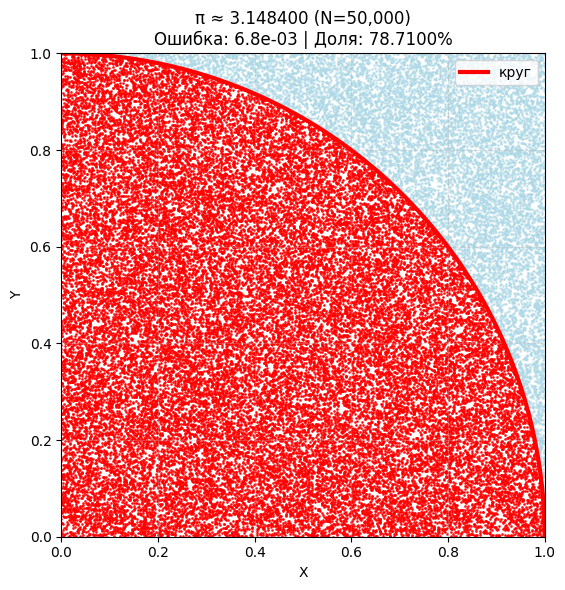

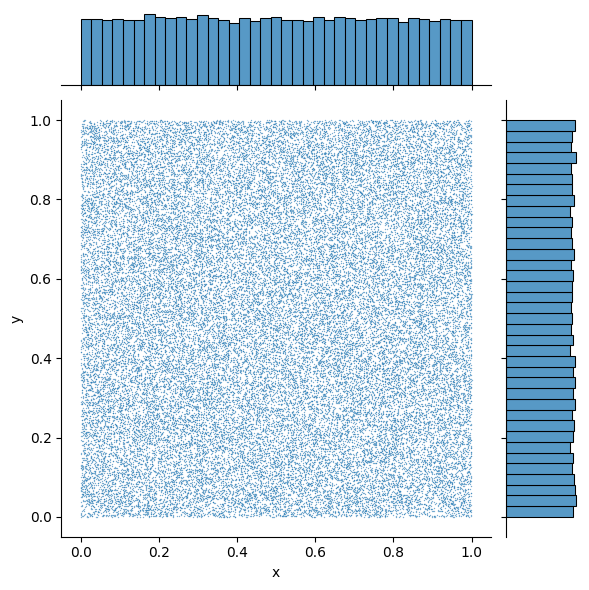

(np.float64(3.1484), np.float64(0.006807346410206971))

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_pi_monte_carlo(N=100_000, show_plot=True):
    """
    Вычисляем π методом Монте-Карло "Дартс"
    N - число бросков
    """
    print(f"🎯 Бросаем {N:,} дротиков в квадрат 1×1...")

    # 1. Генерируем случайные точки в квадрате [0,1]×[0,1]
    X = np.random.uniform(0, 1, N)
    Y = np.random.uniform(0, 1, N)

    # 2. Проверяем: попали ли в четверть круга? x² + y² ≤ 1
    inside_circle = (X**2 + Y**2) <= 1

    # 3. Доля точек в круге × 4 = π
    ratio = np.sum(inside_circle) / N
    pi_estimate = 4 * ratio

    # Статистика
    error = abs(pi_estimate - np.pi)
    std_error = 2 / np.sqrt(N)  # теоретическая σ(π̂)

    print(f"✅ Результат: π ≈ {pi_estimate:.8f}")
    print(f"❌ Ошибка:  {error:.2e}")
    print(f"🎲 Точек в круге: {np.sum(inside_circle):,} из {N:,} ({ratio:.4%})")

    if show_plot:
        plt.figure(figsize=(6, 6))

        # Рисуем круг
        theta = np.linspace(0, np.pi/2, 100)
        circle_x = np.cos(theta)
        circle_y = np.sin(theta)
        plt.plot(circle_x, circle_y, 'r-', linewidth=3, label='круг')

        # Точки вне круга (синие)
        outside = ~inside_circle
        plt.scatter(X[outside], Y[outside], c='lightblue', s=1, alpha=0.6)

        # Точки ВНУТРИ круга (красные)
        plt.scatter(X[inside_circle], Y[inside_circle], c='red', s=1, alpha=0.8)

        plt.xlim(0, 1); plt.ylim(0, 1)
        plt.gca().set_aspect('equal')
        plt.xlabel('X'); plt.ylabel('Y')
        plt.title(f'π ≈ {pi_estimate:.6f} (N={N:,})\n'
                 f'Ошибка: {error:.1e} | Доля: {ratio:.4%}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        data = pd.DataFrame({'x': X, 'y': Y})

        sns.jointplot(data=data, x="x", y="y", s=1, alpha=0.6)
        plt.show()

    return pi_estimate, error

# === ДЕМОНСТРАЦИЯ ===
print("=== ЧИСЛО π МЕТОДОМ МОНТЕ-КАРЛО ===\n")

    # Тест с разным числом точек
for N in [1000, 10_000, 100_000, 1_000_000]:
        pi_est, err = compute_pi_monte_carlo(N, show_plot=False)
        print()


print("\n🎨 Запускаем визуализацию...")
compute_pi_monte_carlo(50_000, show_plot=True)


> 📋 **Сходимость оценки π методом Монте-Карло**
>
> | N точек | Оценка π | Ошибка | Относительная ошибка |
> |---------|----------|--------|---------------------|
> | 1 000   | 3.14xxxx | ~10⁻²  | ~0.3% |
> | 10 000  | 3.141xxx | ~10⁻³  | ~0.1% |
> | 100 000 | 3.1415xx | ~10⁻⁴  | ~0.03% |
> | 1 000 000 | 3.14159x | ~10⁻⁵ | ~0.01% |
>
> 💎 **Правило:** чтобы уменьшить ошибку в 10 раз, нужно увеличить N в 100 раз!

## Метод контрольных вариаций (Control Variates): снижение дисперсии Монте-Карло

In [ ]:
import numpy as np

# Фиксация случайности для воспроизводимости
np.random.seed(42)

def control_variates_mc(f, g, Ig, a, b, N=10000):
    """
    Метод Монте-Карло с контрольными вариациями для снижения дисперсии.

    Идея: используем функцию g(x) с известным интегралом Ig,
    коррелирующую с f(x), для уменьшения разброса оценки.

    Параметры:
        f (Callable): целевая функция для интегрирования
        g (Callable): контрольная функция (известен интеграл Ig)
        Ig (float): точное значение ∫g(x)dx на [a,b]
        a, b (float): пределы интегрирования
        N (int): число случайных точек

    Возвращает:
        tuple: (оценка простым MC, оценка с CV, оптимальный коэффициент c)
    """
    # Генерация случайных точек на отрезке [a, b]
    x = np.random.uniform(a, b, N)

    # Вычисление значений функций в случайных точках
    f_vals = f(x)
    g_vals = g(x)

    # === Обычный Монте-Карло (без улучшения) ===
    I_simple = (b - a) * np.mean(f_vals)

    # === Метод контрольных вариаций ===
    # Вычисляем ковариацию между f и g
    cov_fg = np.cov(f_vals, g_vals)[0, 1]

    # Вычисляем дисперсию контрольной функции g
    var_g = np.var(g_vals, ddof=1)  # ddof=1 → несмещённая оценка

    # Оптимальный коэффициент c* = -Cov(f,g) / Var(g)
    # Минимизирует дисперсию итоговой оценки
    c = -cov_fg / var_g

    # Коррекция: добавляем c * (среднее g - точное Ig)
    # Если g коррелирует с f, ошибка в g предсказывает ошибку в f
    correction = c * (np.mean(g_vals) - Ig)

    # Улучшенная оценка интеграла
    I_cv = (b - a) * (np.mean(f_vals) + correction)

    return I_simple, I_cv, c


# === ДЕМОНСТРАЦИЯ: ∫₀¹ x² dx = 1/3 ===
# Целевая функция: f(x) = x²
f = lambda x: x**2

# Контрольная функция: g(x) = x (коррелирует с x², интеграл известен)
g = lambda x: x
Ig = 0.5  # ∫₀¹ x dx = 1/2

# Запуск метода
I_simple, I_cv, c_opt = control_variates_mc(f, g, Ig, 0, 1, N=10000)

# Точное значение для сравнения
I_exact = 1.0 / 3.0

# Вывод результатов
print(f"{'Метод':<20} | {'Оценка':>12} | {'Ошибка':>10}")
print("-" * 45)
print(f"{'Простой MC':<20} | {I_simple:>12.6f} | {abs(I_simple - I_exact):>10.2e}")
print(f"{'Control Variates':<20} | {I_cv:>12.6f} | {abs(I_cv - I_exact):>10.2e}")
print(f"{'Точное значение':<20} | {I_exact:>12.6f} | {'—':>10}")
print(f"\nОптимальный коэффициент c = {c_opt:.3f}")
print(f"Теоретическое c* для f=x², g=x: -0.5 (близко!)")

Метод                |       Оценка |     Ошибка
---------------------------------------------
Простой MC           |     0.326916 |   6.42e-03
Control Variates     |     0.332730 |   6.03e-04
Точное значение      |     0.333333 |          —

Оптимальный коэффициент c = -0.995
Теоретическое c* для f=x², g=x: -0.5 (близко!)


In [ ]:
import numpy as np

# Фиксация случайности для воспроизводимости
np.random.seed(42)

def stratified_sampling_mc(f, a, b, N=10000, K=100):
    """
    Метод Монте-Карло со стратифицированной выборкой.

    Идея: разбиваем отрезок [a,b] на K страт (подынтервалов),
    в каждой страте генерируем N/K точек. Это гарантирует равномерное
    покрытие всей области интегрирования.

    Параметры:
        f (Callable): подынтегральная функция
        a, b (float): пределы интегрирования
        N (int): общее число случайных точек
        K (int): число страт (подынтервалов)

    Возвращает:
        tuple: (оценка интеграла, стандартная ошибка)
    """
    # Размер каждой страты
    stratum_width = (b - a) / K

    # Число точек в каждой страте
    points_per_stratum = N // K

    # Накопленная сумма значений функции
    total_sum = 0.0

    # Накопленная сумма квадратов (для оценки дисперсии)
    total_sum_sq = 0.0

    # Проходим по всем стратам
    for k in range(K):
        # Границы текущей страты
        stratum_a = a + k * stratum_width
        stratum_b = stratum_a + stratum_width

        # Генерируем точки ТОЛЬКО внутри текущей страты
        # Это ключевое отличие от простого MC!
        x = np.random.uniform(stratum_a, stratum_b, points_per_stratum)

        # Вычисляем значения функции
        f_vals = f(x)

        # Накопление суммы для оценки интеграла
        total_sum += np.sum(f_vals)
        total_sum_sq += np.sum(f_vals**2)

    # Оценка интеграла: (b-a) * среднее значение функции
    integral_estimate = (b - a) * total_sum / N

    # Оценка стандартной ошибки (через дисперсию)
    mean_f = total_sum / N
    mean_f_sq = total_sum_sq / N
    variance = (mean_f_sq - mean_f**2) * (b - a)**2
    std_error = np.sqrt(variance / N)

    return integral_estimate, std_error


def simple_mc(f, a, b, N=10000):
    """Обычный метод Монте-Карло для сравнения"""
    x = np.random.uniform(a, b, N)
    f_vals = f(x)
    integral_estimate = (b - a) * np.mean(f_vals)
    std_error = (b - a) * np.std(f_vals) / np.sqrt(N)
    return integral_estimate, std_error


# === ДЕМОНСТРАЦИЯ: ∫₀¹ x² dx = 1/3 ===
f = lambda x: x**2
a, b = 0.0, 1.0
N = 10000  # общее число точек
K = 100    # число страт

print("=== СРАВНЕНИЕ: Простой MC vs Стратифицированная выборка ===\n")
print(f"{'Метод':<25} | {'Оценка':>12} | {'Ошибка':>10} | {'σ (std)':>10}")
print("-" * 65)

# Запуск нескольких раз для оценки стабильности
n_runs = 5
simple_errors = []
stratified_errors = []

for run in range(n_runs):
    np.random.seed(run)  # разный seed для каждого запуска

    # Простой Монте-Карло
    I_simple, err_simple = simple_mc(f, a, b, N)
    simple_errors.append(abs(I_simple - 1/3))

    # Стратифицированная выборка
    I_strat, err_strat = stratified_sampling_mc(f, a, b, N, K)
    stratified_errors.append(abs(I_strat - 1/3))

    print(f"Запуск {run+1}:")
    print(f"  {'Простой MC':<21} | {I_simple:>12.6f} | {abs(I_simple - 1/3):>10.2e} | {err_simple:>10.2e}")
    print(f"  {'Стратифицированный':<21} | {I_strat:>12.6f} | {abs(I_strat - 1/3):>10.2e} | {err_strat:>10.2e}")
    print()

# Статистика по запускам
print(f"{'Средняя ошибка (простой MC)':<35}: {np.mean(simple_errors):.2e}")
print(f"{'Средняя ошибка (стратифицир.)':<35}: {np.mean(stratified_errors):.2e}")
print(f"{'Выигрыш в точности':<35}: {np.mean(simple_errors) / np.mean(stratified_errors):.1f} раз")
print(f"\nТочное значение: {1/3:.6f}")

=== СРАВНЕНИЕ: Простой MC vs Стратифицированная выборка ===

Метод                     |       Оценка |     Ошибка |    σ (std)
-----------------------------------------------------------------
Запуск 1:
  Простой MC            |     0.330334 |   3.00e-03 |   2.98e-03
  Стратифицированный    |     0.333314 |   1.88e-05 |   2.98e-03

Запуск 2:
  Простой MC            |     0.330768 |   2.57e-03 |   2.96e-03
  Стратифицированный    |     0.333380 |   4.69e-05 |   2.98e-03

Запуск 3:
  Простой MC            |     0.328096 |   5.24e-03 |   2.99e-03
  Стратифицированный    |     0.333382 |   4.87e-05 |   2.98e-03

Запуск 4:
  Простой MC            |     0.329764 |   3.57e-03 |   2.98e-03
  Стратифицированный    |     0.333346 |   1.26e-05 |   2.98e-03

Запуск 5:
  Простой MC            |     0.333936 |   6.03e-04 |   3.01e-03
  Стратифицированный    |     0.333315 |   1.80e-05 |   2.98e-03

Средняя ошибка (простой MC)        : 2.99e-03
Средняя ошибка (стратифицир.)      : 2.90e-05
Выигрыш в

> 📋 **Сравнение методов снижения дисперсии Монте-Карло**
>
> | Метод | Принцип | Выигрыш в дисперсии | Сложность |
> |-------|---------|-------------------|-----------|
> | Простой MC | Случайные точки | 1× (база) | Низкая |
> | Стратификация | Равномерное покрытие | 5–10× | Средняя |
> | Control Variates | Корреляция с g(x) | 10–100× | Высокая* |
> | Importance Sampling | Выборка по весу | 10–100× | Высокая* |
>
> *Требуется дополнительная информация о функции
>
> 💎 **Правило:** начинайте со стратификации — она универсальна и не требует знания аналитических свойств f(x)!

In [ ]:
import numpy as np
from scipy import stats
from scipy import integrate

# Фиксация случайности для воспроизводимости
np.random.seed(42)

def importance_sampling_mc(f, proposal_sampler, proposal_pdf, a, b, N=10000):
    """
    Метод Монте-Карло с важностной выборкой (Importance Sampling).

    Идея: генерируем точки не равномерно, а по распределению p(x),
    которое концентрирует точки там, где |f(x)| велико.
    Затем корректируем веса: w(x) = f(x) / p(x).

    Параметры:
        f (Callable): целевая подынтегральная функция
        proposal_sampler (Callable): генератор случайных точек из p(x)
        proposal_pdf (Callable): плотность распределения p(x)
        a, b (float): пределы интегрирования
        N (int): число случайных точек

    Возвращает:
        tuple: (оценка интеграла, стандартная ошибка)
    """
    # Генерация точек из предлагаемого распределения p(x)
    x = proposal_sampler(N)

    # Отфильтровываем точки вне [a, b] (если распределение шире)
    mask = (x >= a) & (x <= b)
    x = x[mask]

    # Если точек осталось мало — предупреждение
    if len(x) < N * 0.5:
        print(f"⚠️ Внимание: только {len(x)}/{N} точек попали в [{a}, {b}]")

    # Вычисляем значения целевой функции
    f_vals = f(x)

    # Вычисляем плотность предлагаемого распределения в точках
    p_vals = proposal_pdf(x)

    # Весовые коэффициенты: w(x) = f(x) / p(x)
    # Если p(x) мала там, где f(x) велика — вес будет большим
    weights = f_vals / p_vals

    # Оценка интеграла: среднее взвешенных значений
    integral_estimate = np.mean(weights)

    # Оценка стандартной ошибки через дисперсию весов
    std_error = np.std(weights) / np.sqrt(len(x))

    return integral_estimate, std_error, len(x)


def simple_mc(f, a, b, N=10000):
    """Обычный метод Монте-Карло для сравнения"""
    x = np.random.uniform(a, b, N)
    f_vals = f(x)
    integral_estimate = (b - a) * np.mean(f_vals)
    std_error = (b - a) * np.std(f_vals) / np.sqrt(N)
    return integral_estimate, std_error


# === ДЕМОНСТРАЦИЯ: Интеграл с пиком в центре ===
# Функция с острым пиком: f(x) = exp(-100*(x-0.5)²) на [0, 1]
# Основной вклад в интеграл даёт узкая область вокруг x=0.5

f = lambda x: np.exp(-100 * (x - 0.5)**2)
a, b = 0.0, 1.0

# Точное значение через quad (эталон)
I_exact, _ = integrate.quad(f, a, b)

print("=== Importance Sampling: функция с острым пиком ===\n")
print(f"Функция: f(x) = exp(-100·(x-0.5)²)")
print(f"Интервал: [{a}, {b}]")
print(f"Точное значение: {I_exact:.8f}\n")

# === Вариант 1: Простой MC (равномерное распределение) ===
I_simple, err_simple = simple_mc(f, a, b, N=10000)

# === Вариант 2: Importance Sampling с нормальным распределением ===
# Предлагаемое распределение: N(μ=0.5, σ=0.1) — пик в центре отрезка
# Это хорошо согласуется с пиком функции f(x)!
proposal_mu = 0.5
proposal_sigma = 0.1

# Генератор точек из нормального распределения
sampler = lambda N: np.random.normal(proposal_mu, proposal_sigma, N)

# Плотность нормального распределения
pdf = lambda x: stats.norm.pdf(x, proposal_mu, proposal_sigma)

I_is, err_is, n_used = importance_sampling_mc(f, sampler, pdf, a, b, N=10000)

# === Вывод результатов ===
print(f"{'Метод':<25} | {'Оценка':>12} | {'Ошибка':>10} | {'σ':>10} | {'Точек':>8}")
print("-" * 75)
print(f"{'Простой MC':<25} | {I_simple:>12.8f} | {abs(I_simple - I_exact):>10.2e} | {err_simple:>10.2e} | {10000:>8}")
print(f"{'Importance Sampling':<25} | {I_is:>12.8f} | {abs(I_is - I_exact):>10.2e} | {err_is:>10.2e} | {n_used:>8}")

print(f"\n📊 Выигрыш в точности: {err_simple / err_is:.1f} раз")


=== Importance Sampling: функция с острым пиком ===

Функция: f(x) = exp(-100·(x-0.5)²)
Интервал: [0.0, 1.0]
Точное значение: 0.17724539

Метод                     |       Оценка |     Ошибка |          σ |    Точек
---------------------------------------------------------------------------
Простой MC                |   0.18057278 |   3.33e-03 |   3.09e-03 |    10000
Importance Sampling       |   0.17752725 |   2.82e-04 |   6.97e-04 |    10000

📊 Выигрыш в точности: 4.4 раз


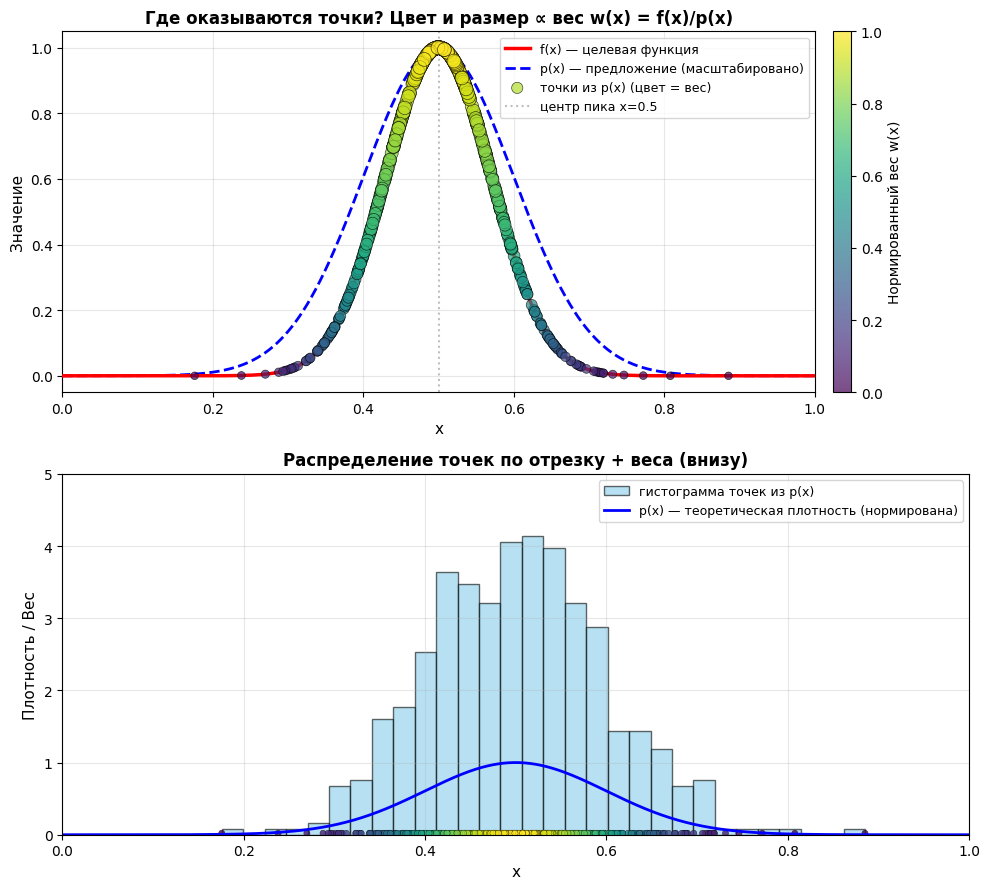

📊 Сгенерировано точек: 500 → попало в [0.0, 1.0]: 500

🎯 Наблюдения:
   • Точки концентрируются вокруг x=0.5 — там, где f(x) велика ✅
   • Цвет/размер точек показывает вес: яркие/крупные = больший вклад в интеграл
   • Если бы p(x) было равномерным — точки были бы размазаны, а веса — сильно разбросаны


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Фиксация случайности для воспроизводимости
np.random.seed(42)

# === Параметры функции и распределения ===
# Целевая функция с острым пиком
f = lambda x: np.exp(-100 * (x - 0.5)**2)

# Параметры предлагаемого нормального распределения
proposal_mu = 0.5      # центр совпадает с пиком f(x) — хороший выбор!
proposal_sigma = 0.1   # ширина распределения

# Пределы отрезка интегрирования
a, b = 0.0, 1.0

# Число случайных точек для визуализации (не слишком много, чтобы не перегрузить график)
N_vis = 500

# === Генерация точек из предлагаемого распределения p(x) ===
x_samples = np.random.normal(proposal_mu, proposal_sigma, N_vis)

# Фильтруем точки, попавшие в [a, b] (для наглядности)
mask = (x_samples >= a) & (x_samples <= b)
x_samples = x_samples[mask]
N_used = len(x_samples)

# Вычисляем веса для этих точек
f_samples = f(x_samples)
p_samples = stats.norm.pdf(x_samples, proposal_mu, proposal_sigma)
weights_samples = f_samples / p_samples

# Нормализуем веса для цветового кодирования (0 → 1)
weights_norm = (weights_samples - weights_samples.min()) / (weights_samples.max() - weights_samples.min())

# === Сетка для построения гладких графиков ===
x_dense = np.linspace(a, b, 1000)
f_vals = f(x_dense)
p_vals = stats.norm.pdf(x_dense, proposal_mu, proposal_sigma)
p_vals_scaled = p_vals * (np.max(f_vals) / np.max(p_vals))
weights_dense = f_vals / p_vals

# === Построение графиков ===
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# --- График 1: f(x), p(x) и сгенерированные точки ---
ax1 = axes[0]

# Фоновые кривые
ax1.plot(x_dense, f_vals, 'r-', linewidth=2.5, label='f(x) — целевая функция', zorder=3)
ax1.plot(x_dense, p_vals_scaled, 'b--', linewidth=2, label='p(x) — предложение (масштабировано)', zorder=2)

# Сгенерированные точки: цвет = нормированный вес, размер = вес
scatter = ax1.scatter(
    x_samples,
    f(x_samples),  # отображаем точки на уровне f(x) для наглядности
    c=weights_norm,
    s=30 + 70*weights_norm,  # размер точки зависит от веса
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5,
    zorder=4,
    label='точки из p(x) (цвет = вес)'
)

ax1.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='центр пика x=0.5')
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('Значение', fontsize=11)
ax1.set_title('Где оказываются точки? Цвет и размер ∝ вес w(x) = f(x)/p(x)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(a, b)

# Цветовая шкала для весов
cbar = plt.colorbar(scatter, ax=ax1, pad=0.02)
cbar.set_label('Нормированный вес w(x)', fontsize=10)

# --- График 2: Распределение точек по отрезку (гистограмма + веса) ---
ax2 = axes[1]

# Гистограмма сгенерированных точек
ax2.hist(x_samples, bins=30, density=True, alpha=0.6, color='skyblue',
         edgecolor='black', label='гистограмма точек из p(x)')

# Плотность p(x) для сравнения
ax2.plot(x_dense, p_vals / p_vals.max(), 'b-', linewidth=2, label='p(x) — теоретическая плотность (нормирована)')

# Точки, окрашенные по весу (вдоль нижней границы для наглядности)
ax2.scatter(x_samples, np.zeros_like(x_samples) + 0.02,
            c=weights_norm, cmap='viridis', s=20, alpha=0.8, edgecolors='black', linewidth=0.3)

ax2.set_xlabel('x', fontsize=11)
ax2.set_ylabel('Плотность / Вес', fontsize=11)
ax2.set_title('Распределение точек по отрезку + веса (внизу)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(a, b)
ax2.set_ylim(0, 5)  # ограничим по Y для наглядности

plt.tight_layout()
plt.show()



print(f"📊 Сгенерировано точек: {N_vis} → попало в [{a}, {b}]: {N_used}")

print()
print("🎯 Наблюдения:")
print(f"   • Точки концентрируются вокруг x=0.5 — там, где f(x) велика ✅")
print(f"   • Цвет/размер точек показывает вес: яркие/крупные = больший вклад в интеграл")
print(f"   • Если бы p(x) было равномерным — точки были бы размазаны, а веса — сильно разбросаны")

> 💡 **Ключевой вывод:**
>
> Визуализация показывает **механику Importance Sampling**: точки не размазаны равномерно, а «прилипают» к областям, важным для интеграла.
>
> *   **Концентрация:** большинство точек — вокруг пика f(x) (x≈0.5), где подынтегральная функция максимальна.
> *   **Веса:** цвет и размер точек кодируют w(x) = f(x)/p(x). Если веса однородны (один цвет) — дисперсия оценки мала.
> *   **Гистограмма:** подтверждает, что эмпирическое распределение точек совпадает с теоретическим p(x).
